# **第二次讀書會專案：BBC對美伊衝突的報導中，主要關注的議題面向為何？**




**課程：** 社群媒體分析  
**教授：** 黃三益 老師  
**組別：** 第 9 組  
**組員：** 楊凱傑 N134020003、陳信宏 N134020006、郭羽庭 N134320008、

黎書宏 N134020009、鍾宛樺 N134320013、盧柔樺 N134320016


#**1.第六周(詞彙關係)**





##1.1.資料說明


英國廣播公司（BBC）作為全球具影響力的新聞媒體，其報導內容具備一定的代表性與可信度。因此，本研究選擇BBC關於「美伊衝突」相關新聞作為分析對象，並以「BBC在報導美伊衝突時，主要關注的議題面向為何？」為核心研究問題，透過文本分析方法探討其報導內容中的關鍵詞彙與主題結構，以理解媒體如何呈現此類國際衝突議題。

##1.2.研究動機


在面對大量新聞資訊時，讀者往往難以快速掌握報導的核心內容與隱含脈絡。因此，本研究希望透過資料分析技術，有系統地萃取文本中的關鍵訊息，並進一步回答BBC在報導美伊衝突時，主要聚焦於哪些議題面向。


1.   釐清新聞報導的核心議題：透過詞彙分析與主題模型，找出BBC在報導美伊衝突時最關注的議題與重點。
2.   探討國際衝突的報導脈絡：分析不同國家（如美國、伊朗、以色列）在新聞中的關聯性與互動關係，理解媒體如何建構衝突敘事。
3.   驗證文本分析方法的應用價值：透過斷詞、TF-IDF與N-gram等方法，實際應用於新聞資料分析，作為回答研究問題的工具，並提升對文本分析技術的理解。

##1.3.研究流程

*   建立文本資料處理流程:

透過爬蟲資料整理、斷句、斷詞與停用詞處理，建構完整的文本分析前處理流程。
*   分析關鍵詞彙分布:

利用詞頻統計與TF-IDF方法，找出新聞中最具代表性與重要性的關鍵詞。
*   探討詞彙關係與語意結構:

透過Bigram與Trigram分析，觀察詞彙之間的共現關係，進一步理解文本中的語意脈絡與議題連結。
*   歸納新聞主題與議題重點:

綜合分析結果，整理BBC在美伊戰爭報導中的主要關注面向，例如軍事衝突、國際政治關係與能源議題等。

#2.**資料處理**


本組已自行撰寫爬蟲程式，自動抓取 BBC 上與美伊戰爭相關的新聞文章，並完成初步的資料蒐集。本次讀書會將上述擷取之資料自 Google 雲端下載並匯入Colab，以利後續進行資料分析與相關處理。

用於管理程式的訊息輸出（如 debug、warning、error 等），以減少不必要的版面干擾。


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import logging
logging.getLogger('gensim').setLevel(logging.ERROR)

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

自動化檔案上傳流程，減少人工處理並提升作業效率。

In [ ]:
import gdown
import pandas as pd

file_id = '1v_5BW3DAEbZ4o2Vgh95o5oboIa0HjiBS'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'war.xlsx'

gdown.download(url, output, quiet=False)

MetaData = pd.read_excel(output, engine='openpyxl')

# 清理欄位名稱
MetaData.columns = MetaData.columns.str.strip()

# rename
MetaData = MetaData.rename(columns={
    'link': 'artUrl',
    'title': 'artTitle',
    'date': 'artDate',
    'content': 'artContent'
})
# 刪除不需要的欄位
MetaData = MetaData.drop(columns=['post_id'])

MetaData.head(3)

Downloading...
From: https://drive.google.com/uc?id=1v_5BW3DAEbZ4o2Vgh95o5oboIa0HjiBS
To: /content/war.xlsx
100%|██████████| 128k/128k [00:00<00:00, 4.23MB/s]


,system_id,artTitle,artDate,artUrl,artContent
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...
1,1,Why did US and Israel attack Iran and how long...,2026-02-28T09:03:32.279Z,https://www.bbc.co.uk/news/articles/cx2dyz6p3weo,Conflict across the Middle East continues to r...
2,18,US-Israel war with Iran: Mapping strikes acros...,2026-02-28T16:40:48.148Z,https://www.bbc.co.uk/news/articles/c4g0pnnj8xyo,US President Donald Trump has postponed his th...


## 2.1.斷句處理

本研究首先將BBC新聞文本依標點符號進行斷句處理，將原始文章拆分為單一句子作為分析單位。此步驟可有效降低文本長度差異對分析的影響，並提升後續詞彙分析的精確度。同時，透過移除非英文字元與無意義句子，確保資料品質，使分析更聚焦於實際新聞內容。

套件安裝

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math

# NLTK
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')   # 新版需要
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import ngrams, FreqDist

# 其他工具
from collections import Counter, namedtuple
import networkx as nx

# sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


首先，先依標點符號對文本進行斷句，接著移除句子中的特殊字元與標點符號，僅保留英文字母，以利後續分析。




In [ ]:
import pandas as pd
import re


# 依標點符號進行斷句
sentence_df = MetaData.copy()
sentence_df['sentence'] = sentence_df['artContent'].str.split(r"[,，。！!？?]+")

# 將句子展開成一行一句
sentence_df = sentence_df.explode('sentence').reset_index(drop=True)

# 定義文字清理函式（只保留英文字母）
def clean_english(text):
    if pd.isna(text):
        return ''
    text = re.sub('[^A-Za-z]+', ' ', str(text))
    return text.strip()

# 對句子進行清理
sentence_df['sentence'] = sentence_df['sentence'].apply(clean_english)

# 移除空白句子
sentence_df = sentence_df[sentence_df['sentence'] != '']

# 移除無意義句子（使用關鍵字過濾）
sentence_df = sentence_df[
    ~sentence_df['sentence'].str.contains(
        'video can not be played|bbc sounds',
        case=False,
        na=False
    )
]

# 查看結果
sentence_df.head(5)

,system_id,artTitle,artDate,artUrl,artContent,sentence
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz
1,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels
2,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,since the US and Israel attacked the country o...
3,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,the corridor only about km miles wide at its e...
4,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,and about km wide at its narrowest point conne...


## 2.2.斷詞處理

In [ ]:
# 新增停用字
nltk.download('stopwords')
stopWords = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

在原始文本處理過程中，本組最初採用 **Stemming（詞幹提取）** 作為詞彙還原方法。然而，在第一次報告時，老師指出 Stemming 可能會過度簡化詞彙，導致語意不夠精準。

例如：
- 單字 **gas** 經過 stemming 處理後，可能被截斷為 **ga**
- 此類結果會破壞原本詞彙的語意，影響後續分析（如詞頻與 TF-IDF）

因此，本組在修正後改採用 **Lemmatization（詞形還原）** 方法，並搭配詞性標註（POS tagging）進行處理。

Lemmatization 的優點包括：
- 保留完整詞彙語意（如 *running → run*）
- 根據詞性進行正確還原
- 避免過度裁切造成的語意錯誤

透過此調整，可以提升文本分析的準確性，使詞彙結果更具解釋力與可靠性。

In [ ]:
import re
import pandas as pd
import nltk

from nltk import pos_tag
from nltk.corpus import wordnet, stopwords
from nltk.stem import WordNetLemmatizer

# 初始化
lemmatizer = WordNetLemmatizer()
all_stopwords = set(stopwords.words('english'))

# 關鍵詞保護
keep_words = {"US", "IRAN", "IRAQ", "ISRAEL", "UK"}

# normalization（用 regex，避免誤替換）
normalize_patterns = {
    r"\bu\.s\.\b": "US",              # u.s. → US
    r"\busa\b": "US",                # usa → US
    r"\bunited states\b": "US",      # united states → US
    r"\biranian\b": "IRAN",          # iranian → IRAN
    r"\bisraeli\b": "ISRAEL",        # israeli → ISRAEL
    r"\bindian\b": "INDIA",          # indian → INDIA
    r"\bindia\b": "INDIA"            # india → INDIA
}

# POS 轉換
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


def normalize_text(text):
    for pattern, repl in normalize_patterns.items():
        text = re.sub(pattern, repl.lower(), text)
    return text


def getToken(text):
    if pd.isna(text):
        return []

    text = str(text).lower()

    # normalization
    text = normalize_text(text)

    words = nltk.word_tokenize(text)
    pos_tags = pos_tag(words)

    tokens = []

    for w, pos in pos_tags:
        w_upper = w.upper()

        # 關鍵詞保護
        if w_upper in keep_words:
            tokens.append(w_upper)
            continue

        # 先過濾再lemma
        if not w.isalpha() or len(w) <= 1 or w in all_stopwords:
            continue

        lemma = lemmatizer.lemmatize(w, get_wordnet_pos(pos))
        tokens.append(lemma)

    return tokens

In [ ]:
# 複製斷句後的資料
token_df = sentence_df.copy()

# 對句子進行斷詞
token_df['word'] = token_df['sentence'].apply(getToken)

# 展開詞彙
token_df = token_df.explode('word')

# 重設索引
token_df.reset_index(inplace=True, drop=True)

# 查看結果
token_df.head()

,system_id,artTitle,artDate,artUrl,artContent,sentence,word
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,IRAN
1,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,effectively
2,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,block
3,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,strait
4,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,hormuz


先統計文本中各詞彙之出現頻率以建立詞頻資料表，並進一步引入自定義停用字，以提升後續文本分析之準確性與代表性。

In [ ]:
freq_df = pd.DataFrame(token_df['word'].value_counts()).reset_index()
freq_df.columns = ['word', 'frequency']
print(freq_df.head(20))

         word  frequency
0        IRAN        627
1         say        478
2          US        382
3         war        251
4      ISRAEL        204
5       trump        202
6      attack        172
7      strike        168
8         oil        147
9       price        136
10       also        135
11    country        124
12      india        120
13        bbc        111
14     strait        106
15  president        105
16   military         95
17      since         90
18        day         90
19       base         87


## 2.3.加入自定義停用詞

在初步詞頻統計結果中，可以觀察到除了核心關鍵詞如 **IRAN、US、war、ISRAEL** 外，亦出現多個高頻但語意貢獻較低的詞彙，例如 **say、also、country、time、people** 等。

這些詞彙雖然出現頻率高，但多屬於新聞報導中的常見用語，對於主題判斷與語意分析的幫助有限，容易造成分析結果的干擾。

因此，本研究根據詞頻結果，進一步人工篩選並加入自定義停用詞（extra stopwords），主要包含以下幾類：

- **低語意動詞與助動詞**（如 say、make、take）
- **時間與數量詞**（如 day、time、one）
- **泛用名詞**（如 people、country、government）
- **新聞常用語**（如 report、also、official）
- **媒體來源詞**（如 bbc）

透過加入上述停用詞並重新過濾文本，可以有效降低雜訊干擾，使後續分析（如詞頻與 TF-IDF）更能凸顯與主題相關的重要詞彙，例如軍事行動（attack、strike）與能源議題（oil、price）。

整體而言，此步驟有助於提升文本分析的準確性與代表性，使研究結果更具解釋力。

In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords as nltk_stopwords

# 英文 stopwords
stop_words = set(nltk_stopwords.words('english'))



# 手動 stopwords
extra_stopwords = [

    # 動詞 / 助動詞（低語意）
    "use", "tell", "make", "take", "see", "go",
    "would", "could", "say","begin", "add", "follow", "come",

    # 數量 / 基本詞
    "one", "two",

    # 時間相關
    "day", "week", "time", "last", "since", "march",

    # 泛用名詞
    "people", "country", "state", "government",

    # 新聞語氣 / 常見媒體用語
    "report", "include", "also", "official", "post", "verify",

    # 描述詞
    "long", "across",

    # 媒體來源
    "bbc",
]
#  合併全部 stopwords
all_stopwords = set(stop_words) | set(extra_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


* 移除停用字前 token 數: 25179
* 移除停用字後 token 數: 22335

In [ ]:
noStop_df = token_df[~token_df['word'].isin(all_stopwords)].reset_index(drop=True)

display(noStop_df.head(10))

print(f"移除 stop words 前 token 數: {len(token_df)}")
print(f"移除 stop words 後 token 數: {len(noStop_df)}")

,system_id,artTitle,artDate,artUrl,artContent,sentence,word
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,IRAN
1,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,effectively
2,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,block
3,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,strait
4,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,hormuz
5,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels,world
6,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels,busy
7,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels,oil
8,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels,shipping
9,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels,channel


移除 stop words 前 token 數: 25179
移除 stop words 後 token 數: 22335



根據詞頻統計結果，可以觀察到高頻詞彙包括 **IRAN、US、war、ISRAEL、attack、strike、oil、price、strait、hormuz、missile** 等，整體上與近期美伊衝突局勢具有高度一致性。

首先，在國家與政治面向上：
- **IRAN、US、ISRAEL、trump、president** 等詞顯示主要涉及國家與政治人物  
- 符合當前美國、伊朗與以色列之間的緊張關係與國際關注焦點  

其次，在軍事衝突面向：
- **attack、strike、military、missile、base、conflict** 等詞頻繁出現  
- 顯示新聞內容主要圍繞軍事行動與衝突升溫  
- 符合近期中東地區軍事對峙與攻擊事件的報導趨勢  

再者，在能源與經濟面向：
- **oil、price、gas、fuel** 等詞顯示能源議題的重要性  
- 特別是石油價格波動，與中東衝突密切相關  

最後，在地緣戰略位置上：
- **strait、hormuz**（荷姆茲海峽）為全球重要石油運輸通道  
- 其高頻出現顯示該區域在衝突中的戰略關鍵性  

此外，**india** 的出現也反映出衝突對其他國家（如能源進口國）的間接影響。

綜合而言，詞頻分析結果不僅反映出新聞報導的核心內容，也與近期美伊衝突的實際國際局勢高度吻合，顯示本研究所蒐集之文本資料具有良好的代表性與現實關聯性。

In [ ]:
freq_df = pd.DataFrame(noStop_df['word'].value_counts()).reset_index()
freq_df.columns = ['word', 'frequency']
print(freq_df.head(20))

         word  frequency
0        IRAN        627
1          US        382
2         war        251
3      ISRAEL        204
4       trump        202
5      attack        172
6      strike        168
7         oil        147
8       price        136
9       india        120
10     strait        106
11  president        105
12   military         95
13       base         87
14        gas         84
15   conflict         81
16     tehran         78
17     hormuz         77
18       fuel         69
19    missile         69


# **3.找出重要詞彙 - 以TFIDF為例**

在文本分析中，單純使用詞頻（frequency）雖然可以找出出現次數最多的詞彙，但這些詞未必能真正代表文本的核心主題。例如像「say」、「also」等詞可能出現頻率高，但對於理解內容幫助有限。

因此，本研究進一步採用 **TF-IDF（Term Frequency-Inverse Document Frequency）** 方法，以衡量詞彙在文件中的「重要性」，其實作意義如下：

1. **區分「常見詞」與「關鍵詞」**  
   TF-IDF 會降低在所有文章中都常出現的詞（如通用詞），並提高只在特定文章中具有代表性的詞彙權重。

2. **強調具有主題代表性的詞彙**  
   若某個詞在特定文章中出現頻率高，但在其他文章中較少出現，則該詞會被視為該文章的重要關鍵詞。

3. **提升分析精準度**  
   相較於單純詞頻，TF-IDF 能更有效找出與主題高度相關的詞彙，例如本研究中的「iran」、「war」、「oil」等。

4. **作為後續分析基礎**  
   TF-IDF 結果可用於關鍵詞排名、主題分析，甚至進一步應用於文本分類或相似度計算。

綜合而言，TF-IDF 的實作目的在於從大量文本中篩選出真正具有代表性的詞彙，使分析結果更能反映文本的核心主題。

## 3.1 連接斷詞

在完成斷詞與停用詞過濾後，每篇文章已被拆解為多個獨立詞彙。然而，後續分析方法（如 TF-IDF 與詞頻矩陣）需要以「文件（document）」為單位進行計算，而非單一詞彙。

因此，本步驟將同一篇文章中的所有詞彙重新串接為一段文字，使每筆資料代表一篇完整文件。此處透過 `groupby(system_id)` 將相同文章的詞彙集合，再使用字串串接（join）方式還原為文本格式。


In [ ]:
import pandas as pd
war_df = (
    noStop_df
    .dropna(subset=['word'])
    .groupby('system_id')['word']
    .apply(lambda x: ' '.join([w for w in x if isinstance(w, str)]))
    .reset_index(name='text')
)
war_df

,system_id,text
0,1,conflict middle east continue rageafter US ISR...
1,2,hiring US surge month despite energy shock unc...
2,3,without set timeline end conflict primetime ad...
3,4,primetime televise speech white house roughly ...
4,5,american farmer face intense financial pressur...
5,6,control tower adolfo suarez airport madrid spa...
6,7,member IRAN volunteer militia basij attend teh...
7,8,military expert scale spread damage observe re...
8,9,minister join european union foreign policy ch...
9,10,fuel tom collins tractor double price IRAN war...


## 3.2 詞頻矩陣

在完成文件建構後，本研究進一步建立「詞頻矩陣（Document-Term Matrix, DTM）」，以量化每篇文章中各詞彙的出現次數。

本步驟使用 `CountVectorizer` 將文本轉換為 Bag-of-Words 模型，其核心概念為：

- 每一列（row）代表一篇文章（document）
- 每一欄（column）代表一個詞彙（word）
- 每個數值代表該詞在該文章中出現的次數

In [ ]:
# Bag of Word
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(war_df["text"])
vocabulary = vectorizer.get_feature_names_out()

# 轉成 dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df

,abbas,abbasabad,abdullah,abhishek,ability,able,aboard,aboutsecurity,aboutwhenthe,abroad,...,youth,youtube,yugoslavia,yuna,yvette,zahra,zakani,zamir,zayed,zone
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
8,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## 3.3 統計TF-IDF值

在建立詞頻矩陣（DTM）後，本研究進一步使用 TF-IDF（Term Frequency-Inverse Document Frequency）方法，計算每個詞彙在各篇文章中的重要程度。

TF-IDF 的概念為：
- **TF（詞頻）**：某詞在該文章中出現的頻率
- **IDF（反文件頻率）**：該詞在所有文章中的稀有程度

透過兩者結合，可衡量詞彙在特定文件中的代表性。

In [ ]:
transformer = TfidfTransformer()
# 將詞頻矩陣X統計成TF-IDF值
tfidf = transformer.fit_transform(X)

# 轉成dataframe
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf.toarray())

TFIDF_df

,abbas,abbasabad,abdullah,abhishek,ability,able,aboard,aboutsecurity,aboutwhenthe,abroad,...,youth,youtube,yugoslavia,yuna,yvette,zahra,zakani,zamir,zayed,zone
0,0.000000,0.000000,0.000000,0.000000,0.022770,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.036877,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.025327,0.000000,0.041197,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.034047,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.026580
8,0.034290,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023912


## 3.4 檢視結果

###方法1： 取每一個字詞在所有文件裡的TF-IDF平均值



在取得每篇文章的 TF-IDF 矩陣後，本研究進一步計算「每個詞彙在所有文件中的平均 TF-IDF 值」，以找出整體語料中最具代表性的關鍵詞。

- 將每個詞在所有文件中的 TF-IDF 值取平均  
- 著重於「整體語料」中最重要的詞彙  
- 偏向宏觀（global）分析

In [ ]:
war_tfidf = TFIDF_df.mean().to_frame().reset_index() ## !!
war_tfidf.columns = ["word", "avg"]

war_tfidf.sort_values('avg', ascending = False).head(10)

,word,avg
2054,iran,0.136057
4157,us,0.093853
4043,trump,0.070881
4246,war,0.059960
2075,israel,0.051939
302,attack,0.050501
3754,strike,0.049157
1955,india,0.047374
2687,oil,0.043386
2990,price,0.043234


從結果可觀察到，顯示整體新聞內容主要圍繞：

* **國家（IRAN、US、ISRAEL）**

* **政治人物（Trump）**

* **戰爭與軍事衝突（war、attack、strike）**

* **能源議題（oil、price）**

###方法2： 取每份文件裡TF-IDF值最大的前10個字詞當為常用字詞，再取每一個字詞在常用字詞中出現頻率

- 先在每篇文章中選出 TF-IDF 最高的前10個詞  
- 再統計這些詞在所有文章中出現的次數  
- 著重於「每篇文章的關鍵詞」之共通性  


方法二能避免某些詞只在少數文章中權重很高，卻被誤判為整體重要詞的問題，因此更能反映「多數文章共同關注的主題」。

In [ ]:
toptens = TFIDF_df.copy()
toptens.insert(0, 'doc_id', toptens.index+1)

toptens

,doc_id,abbas,abbasabad,abdullah,abhishek,ability,able,aboard,aboutsecurity,aboutwhenthe,...,youth,youtube,yugoslavia,yuna,yvette,zahra,zakani,zamir,zayed,zone
0,1,0.000000,0.000000,0.000000,0.000000,0.022770,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,6,0.000000,0.000000,0.000000,0.000000,0.000000,0.036877,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,7,0.000000,0.000000,0.000000,0.000000,0.000000,0.025327,0.000000,0.041197,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,8,0.000000,0.034047,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.026580
8,9,0.034290,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023912


In [ ]:
toptens = toptens.melt(id_vars = "doc_id", var_name = "word", value_name = 'tfidf')
toptens

,doc_id,word,tfidf
0,1,abbas,0.0
1,2,abbas,0.0
2,3,abbas,0.0
3,4,abbas,0.0
4,5,abbas,0.0
...,...,...,...
206184,43,zone,0.0
206185,44,zone,0.0
206186,45,zone,0.0
206187,46,zone,0.0


nlargest() 會回傳指定列中最大的前x個值所對應的資料

In [ ]:
(
    # 從每篇文章挑選出tf-idf最大的前十個詞
    toptens.groupby("doc_id").apply(lambda x : x.nlargest(10, "tfidf")).reset_index(drop=True)

    # 計算每個詞被選中的次數
    .groupby(['word'],as_index=False).size()

).sort_values('size', ascending=False).head(10) # 排序看前十名

,word,size
143,iran,18
313,us,16
309,trump,11
20,attack,7
122,gas,5
147,israel,5
324,war,5
289,strike,5
139,india,5
207,oil,4


* **國家與國際關係**(iran、us、israel、india)→ 顯示報導核心圍繞多國之間的政治與軍事互動

* **軍事衝突**(attack、war、strike)→ 顯示文本重點集中於軍事行動與衝突事件

* **能源議題**(oil、gas) → 反映中東衝突對全球能源供應的影響


**方法一結果（平均TF-IDF）:**
- iran、us、trump、war、israel、attack、strike、india、oil、price

特點：包含「price」等詞，反映整體語料中具有平均重要性的詞彙

**方法二結果（Top10統計）：**
- iran、us、trump、attack、gas、israel、war、strike、india、oil

特點：出現「gas」但沒有「price」，代表其為多數文章的共同關鍵詞

# **4.斷詞與N-gram**

在文本分析中，N-gram 用於觀察詞彙之間的連續關係，其中：

 **Bigram（雙詞組）**
- 由「連續兩個詞」組成
- 例如：middle east、oil price、US ISRAEL
- Bigram 可快速掌握主要議題關聯（如 oil + price）

 **Trigram（三詞組）**
- 由「連續三個詞」組成
- 例如：president donald trump、US ISRAEL war
- Trigram 則可進一步理解具體事件或人物（如 president + donald + trump）

## 4.1.Bigram

In [ ]:
from nltk.util import ngrams
def bigram_getToken(text):
    if pd.isna(text):
        return []

    words = nltk.tokenize.word_tokenize(str(text).lower())
    pos_tags = pos_tag(words)

    tokens = []

    for w, pos in pos_tags:

        # 關鍵詞保護
        if w.upper() in keep_words:
            tokens.append(w.upper())
            continue

        # 過濾條件
        if w not in all_stopwords and len(w) > 1 and w.isalpha():
            lemma = lemmatizer.lemmatize(w, get_wordnet_pos(pos))
            tokens.append(lemma)

    # 建立 bigram
    bigrams = list(ngrams(tokens, 2))

    # 轉字串
    bigrams = [" ".join(bg) for bg in bigrams]

    return bigrams

In [ ]:
tp_bigram = sentence_df.copy()
tp_bigram["word"] = tp_bigram.sentence.apply(bigram_getToken)
tp_bigram = tp_bigram.explode('word')
tp_bigram

,system_id,artTitle,artDate,artUrl,artContent,sentence,word
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,IRAN effectively
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,effectively block
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,block strait
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,strait hormuz
1,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels,world busy
...,...,...,...,...,...,...,...
2297,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,material from the conflict we re also looking ...,warn attempt
2297,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,material from the conflict we re also looking ...,attempt transit
2297,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,material from the conflict we re also looking ...,transit key
2297,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,material from the conflict we re also looking ...,key route


統計最常出現的bigram組合

In [ ]:
# 計算每個組合出現的次數
tp_bigram_count = tp_bigram.groupby(["word"],as_index=False).size()
tp_bigram_count.sort_values(by=['size'], ascending=False).head(15)

,word,size
14616,strait hormuz,69
9529,middle east,55
356,US ISRAEL,44
234,IRAN war,43
4573,donald trump,40
10567,oil price,33
16550,war IRAN,32
1611,attack IRAN,27
15938,trump say,26
16940,white house,26


高頻詞組包括：

- strait hormuz（69）
- middle east（55）
- US ISRAEL（44）
- IRAN war（43）
- donald trump（40）
- oil price（33）

___

1. **地緣位置**- strait hormuz、middle east  → 顯示衝突集中於中東與關鍵能源航道

2. **國際關係**- US ISRAEL、IRAN war  → 呈現美國、以色列與伊朗之間的對立關係

3. **經濟影響**- oil price  → 反映戰爭對能源市場的影響

4. **政治人物**- donald trump  → 顯示政治領導人在議題中的重要性

## 4.2 Trigram

In [ ]:
from nltk.util import ngrams

def trigram_getToken(text):
    if pd.isna(text):
        return []

    words = nltk.tokenize.word_tokenize(str(text).lower())
    pos_tags = pos_tag(words)

    tokens = []

    for w, pos in pos_tags:

        # 關鍵詞保護
        if w.upper() in keep_words:
            tokens.append(w.upper())
            continue

        # 過濾
        if w not in all_stopwords and len(w) > 1 and w.isalpha():
            lemma = lemmatizer.lemmatize(w, get_wordnet_pos(pos))
            tokens.append(lemma)

    # trigram
    trigrams = list(ngrams(tokens, 3))
    trigrams = [" ".join(tg) for tg in trigrams]

    return trigrams

In [ ]:
tp_trigram = sentence_df.copy()
tp_trigram["word"] = tp_trigram.sentence.apply(trigram_getToken)
tp_trigram = tp_trigram.explode('word')
tp_trigram

,system_id,artTitle,artDate,artUrl,artContent,sentence,word
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,IRAN effectively block
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,effectively block strait
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,block strait hormuz
1,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels,world busy oil
1,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels,busy oil shipping
...,...,...,...,...,...,...,...
2297,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,material from the conflict we re also looking ...,ship warn attempt
2297,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,material from the conflict we re also looking ...,warn attempt transit
2297,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,material from the conflict we re also looking ...,attempt transit key
2297,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,material from the conflict we re also looking ...,transit key route


統計最常出現的trigram組合

In [ ]:
# 計算每個組合出現的次數
tp_trigram_count = tp_trigram.groupby(["word"],as_index=False).size()
tp_trigram_count.sort_values(by=['size'], ascending=False).head(15)

,word,size
12109,president donald trump,23
655,US president donald,15
10213,minister abbas araghchi,10
8461,islamic revolutionary guard,10
6377,foreign minister abbas,10
13402,revolutionary guard corp,9
11574,pass strait hormuz,9
423,ISRAEL war IRAN,9
485,US ISRAEL attack,9
499,US ISRAEL war,9


高頻詞組包括：

- president donald trump（23）
- US president donald（15）
- islamic revolutionary guard（10）
- ISRAEL war IRAN（9）
- US ISRAEL attack（9）
- attack IRAN war（8）

___

1. **政治人物與決策**- president donald trump  → 顯示政治決策在衝突中的重要角色

2. **軍事組織**- islamic revolutionary guard  → 指向伊朗軍事力量

3. **衝突結構**- US ISRAEL attack、ISRAEL war IRAN  → 清楚呈現「誰攻擊誰」的關係
____

透過 bigram 與 trigram 分析，可以觀察到文本主題主要集中於中東地緣政治衝突，特別是以伊朗為核心的軍事對抗關係（如 Israel–Iran 衝突及 US 介入）。此外，「strait of Hormuz」與「oil price」等詞組顯示該衝突對全球能源供應鏈與石油價格具有顯著影響。同時，文本中亦頻繁出現政治人物（如 Donald Trump）與政府機構（White House），顯示政策決策在該議題中的重要性。

## 4.3.bigram視覺化

In [ ]:
from nltk.util import ngrams
from nltk.probability import FreqDist

bigramfdist = FreqDist()

def bigram_getToken_dict(text):
    if pd.isna(text):
        return []

    words = nltk.tokenize.word_tokenize(str(text).lower())
    pos_tags = pos_tag(words)

    tokens = []

    for w, pos in pos_tags:

        # 關鍵詞保護
        if w.upper() in keep_words:
            tokens.append(w.upper())
            continue

        # 過濾條件
        if w not in all_stopwords and len(w) > 1 and w.isalpha():
            lemma = lemmatizer.lemmatize(w, get_wordnet_pos(pos))
            tokens.append(lemma)

    # 建立 bigram
    bigrams = list(ngrams(tokens, 2))

    # 更新頻率
    bigramfdist.update(bigrams)

    # 轉字串
    bigrams_str = [" ".join(bg) for bg in bigrams]

    return bigrams_str

In [ ]:
fud_bigram2 = sentence_df.copy()
fud_bigram2["word"] = fud_bigram2.sentence.apply(bigram_getToken_dict)
fud_bigram2 = fud_bigram2.explode('word')
fud_bigram2.head(3)

,system_id,artTitle,artDate,artUrl,artContent,sentence,word
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,IRAN effectively
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,effectively block
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,block strait


在取得 Bigram（雙詞組）後，本研究進一步統計各詞組的出現頻率，並將結果轉換為 dictionary（字典）格式，以利後續分析與視覺化。

首先，透過 `bigramfdist.most_common(5)` 檢視出現頻率最高的詞組，例如：

- strait hormuz（69）
- middle east（55）
- US ISRAEL（44）
- IRAN war（43）
- donald trump（40）

接著，使用 `most_common(30)` 取出前30個最常見的詞組，並轉換為 dictionary 格式（key 為詞組，value 為出現次數）。


In [ ]:
# 看一下bigramfdist內容
bigramfdist.most_common(5)

[(('strait', 'hormuz'), 69),
 (('middle', 'east'), 55),
 (('US', 'ISRAEL'), 44),
 (('IRAN', 'war'), 43),
 (('donald', 'trump'), 40)]

In [ ]:
# 建立bigram和count的dictionary
# 這裡取最多的前30項
d = {k:v for k,v in bigramfdist.most_common(30)}
d

{('strait', 'hormuz'): 69,
 ('middle', 'east'): 55,
 ('US', 'ISRAEL'): 44,
 ('IRAN', 'war'): 43,
 ('donald', 'trump'): 40,
 ('oil', 'price'): 33,
 ('war', 'IRAN'): 32,
 ('attack', 'IRAN'): 27,
 ('sri', 'lanka'): 26,
 ('trump', 'say'): 26,
 ('white', 'house'): 26,
 ('strike', 'IRAN'): 25,
 ('US', 'president'): 25,
 ('say', 'US'): 24,
 ('prime', 'minister'): 23,
 ('president', 'donald'): 23,
 ('natural', 'gas'): 22,
 ('oil', 'gas'): 21,
 ('foreign', 'minister'): 20,
 ('US', 'israeli'): 19,
 ('power', 'plant'): 19,
 ('saudi', 'arabia'): 17,
 ('president', 'trump'): 17,
 ('pass', 'strait'): 16,
 ('crude', 'oil'): 16,
 ('US', 'military'): 16,
 ('supreme', 'leader'): 16,
 ('air', 'strike'): 15,
 ('US', 'base'): 15,
 ('military', 'base'): 15}

為了更直觀呈現詞彙之間的關聯性，本研究將 Bigram 結果轉換為網絡圖（network graph），以視覺化詞彙之間的共現關係。


In [ ]:
# Create network plot
G = nx.Graph()

# 建立 nodes 間的連結
for k, v in [d][0].items():
    G.add_edge(k[0], k[1], weight=v)

# 取得edge權重
weights = [w[2]['weight']*0.05 for w in  G.edges(data=True)]

本研究透過 Bigram 網絡圖分析，可以清楚觀察到文本中的關鍵詞與其關聯結構。

* **在核心節點方面**，可以發現「US」、「IRAN」、「ISRAEL」位於網絡中心，且與多個詞彙相連，顯示其為整體文本中的關鍵核心詞。這代表這些國家為國際衝突的主要參與者，同時也是新聞報導的核心焦點。

* **在軍事衝突相關詞彙方面**，與 IRAN、US 連結的詞包含 attack、strike、military、air、base 等，顯示文本主要聚焦於軍事行動與戰爭相關議題，反映中東地區衝突的緊張情勢。

* **在能源議題方面**，出現 oil、gas、price、plant、crude 等詞彙，顯示中東衝突與全球能源市場具有高度關聯性，特別是在石油與天然氣供應層面。

* **在地緣位置相關詞彙中**，可觀察到 middle、east、strait、hormuz 等詞，顯示衝突主要集中於中東地區，其中荷姆茲海峽為重要的戰略位置。

* **在政治人物與政府方面**，包含 trump、president、white、house、prime、minister 等詞，顯示政策決策與政府角色在新聞報導中具有重要影響力。

**綜合而言，文本呈現出以國家為核心，向外延伸至軍事、能源與地緣政治議題的結構，顯示新聞內容具有明確的主題聚焦與關聯性。**

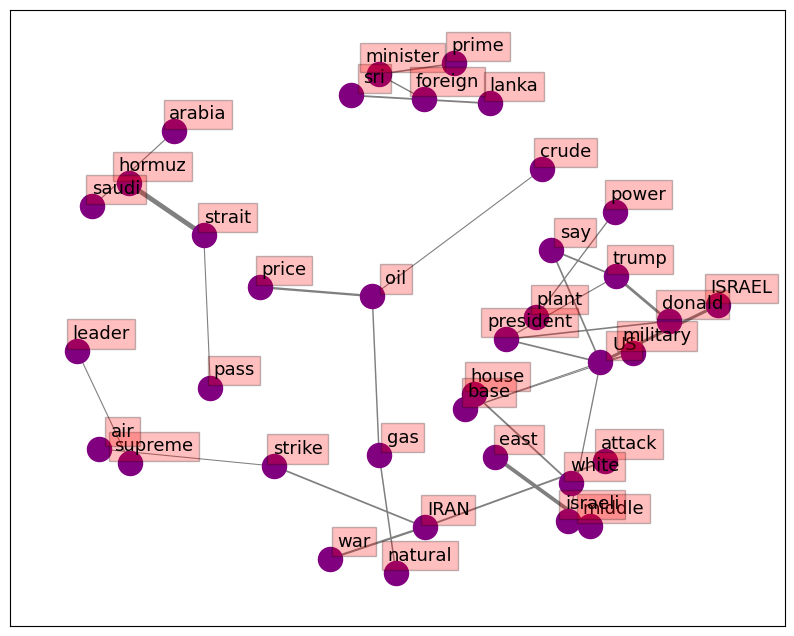

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

pos = nx.spring_layout(G, k=2)

# networks
nx.draw_networkx(G, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='purple',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=13)

plt.show()

詞彙關係網路圖顯示文本中關鍵詞之間的共現關係，各詞彙依其語意關聯形成不同群聚。例如，美國政治相關詞彙（如 president、trump）形成一群，中東衝突相關詞彙（如 iran、war、attack）形成另一群，而能源與經濟詞彙（如 oil、gas、price）亦呈現明顯聚集。顯示新聞內容中不同議題之間具有高度關聯性，並反映其語意結構。

# **5.相關性(Pairwise correlation)**

## 5.1.計算兩個詞彙間的相關性

本研究進一步計算詞彙之間的相關性（correlation），以了解不同詞在各篇文件中的出現模式是否相似。

相關性數值介於 -1 到 1 之間：
- 越接近 1：代表兩詞幾乎總是一起出現（高度正相關）
- 越接近 0：代表兩詞關聯性低
- 越接近 -1：代表兩詞幾乎不會同時出現（負相關）

In [ ]:
data_cor = sentence_df.copy()

# 需要改成使用空格連接斷好的詞
data_cor['word'] = data_cor.sentence.apply(getToken).map(' '.join)
data_cor

,system_id,artTitle,artDate,artUrl,artContent,sentence,word
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,IRAN effectively block strait hormuz
1,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels,world busy oil shipping channel
2,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,since the US and Israel attacked the country o...,US ISRAEL attack february world oil liquefy na...
3,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,the corridor only about km miles wide at its e...,corridor km mile wide entrance exit
4,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,and about km wide at its narrowest point conne...,km wide narrow point connect gulf arabian sea ...
...,...,...,...,...,...,...,...
2293,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,which found it was generated or edited with Go...,find generate edit google ai visual inconsiste...
2294,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,including the unrealistic fireball and unusual...,include unrealistic fireball unusually shaped ...
2295,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,verifying and mapping attacks in Iran and acro...,verifying mapping attack IRAN middle east firs...
2296,39,Debunking AI fake images and disinformation ab...,NaN,https://www.bbc.co.uk/news/live/cvg3qzx512nt,Thomas CopelandBBC Verify Live journalist\nWeâ...,verified,verify


In [ ]:
# Bag of Word
# 篩選至少出現在5篇文章以上且詞頻前300的詞彙
vectorizer = CountVectorizer(min_df = 5, max_features = 300)
X = vectorizer.fit_transform(data_cor["word"])
vocabulary = vectorizer.get_feature_names_out()

# 轉成dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df

,accord,action,add,address,administration,agency,ahead,ai,air,airport,...,way,wednesday,week,well,white,without,woman,work,world,year
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2247,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2248,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2249,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2250,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 計算詞之間的相關係數
corr_matrix = np.corrcoef(DTM_df.T)

# 轉成dataframe
Cor_df = pd.DataFrame(corr_matrix, index = DTM_df.columns, columns = DTM_df.columns)

Cor_df.insert(0, 'word1', Cor_df.columns)
Cor_df.reset_index(inplace = True, drop = True)

Cor_df

,word1,accord,action,add,address,administration,agency,ahead,ai,air,...,way,wednesday,week,well,white,without,woman,work,world,year
0,accord,1.000000,-0.015490,-0.022930,-0.012494,0.015668,0.115560,-0.012494,0.005494,0.018243,...,-0.015375,0.015668,-0.017449,-0.017449,-0.015490,0.019916,-0.012180,-0.015490,-0.021796,0.020230
1,action,-0.015490,1.000000,0.033134,-0.008872,-0.009719,-0.009674,-0.008872,-0.010693,0.010052,...,-0.010918,-0.009719,0.019756,-0.012390,0.020595,0.074713,-0.008648,-0.010999,-0.015477,-0.014339
2,add,-0.022930,0.033134,1.000000,-0.013133,-0.014386,0.017705,-0.013133,-0.015829,-0.020920,...,0.010250,-0.014386,0.006798,0.006798,0.033134,-0.013935,-0.012802,0.008426,-0.002630,-0.021226
3,address,-0.012494,-0.008872,-0.013133,1.000000,-0.007839,-0.007803,-0.007156,0.064948,-0.011399,...,0.086535,0.097239,-0.009994,-0.009994,0.080319,0.051781,-0.006976,-0.008872,-0.012484,-0.011566
4,administration,0.015668,-0.009719,-0.014386,-0.007839,1.000000,-0.008548,-0.007839,-0.009448,-0.012487,...,-0.009647,-0.008587,-0.010948,-0.010948,0.101946,0.041238,-0.007642,-0.009719,-0.013675,0.138299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,without,0.019916,0.074713,-0.013935,0.051781,0.041238,-0.008280,0.051781,0.025546,-0.012096,...,0.035620,-0.008318,-0.010605,0.032194,0.032650,1.000000,-0.007402,0.032650,-0.013247,-0.012273
296,woman,-0.012180,-0.008648,-0.012802,-0.006976,-0.007642,-0.007607,-0.006976,-0.008408,0.082848,...,-0.008584,-0.007642,-0.009742,0.031889,-0.008648,-0.007402,1.000000,-0.008648,-0.012170,-0.011275
297,work,-0.015490,-0.010999,0.008426,-0.008872,-0.009719,0.072228,-0.008872,-0.010693,0.010052,...,-0.010918,-0.009719,-0.012390,-0.012390,-0.010999,0.032650,-0.008648,1.000000,-0.015477,-0.014339
298,world,-0.021796,-0.015477,-0.002630,-0.012484,-0.013675,-0.013613,-0.012484,0.006345,-0.019886,...,0.067802,0.108536,0.008952,0.061725,0.036390,-0.013247,-0.012170,-0.015477,1.000000,0.000859


本次分析中，相關性最高的詞彙組合包括：

- arabia – saudi（0.978）
- sri – lanka（0.907）
- white – house（0.854）
- middle – east（0.854）
- hormuz – strait（0.805）

In [ ]:
word_cor_df = Cor_df.melt(id_vars = 'word1', var_name = 'word2', value_name = 'cor')

# 去除兩個詞相同的情況
word_cor_df = word_cor_df[word_cor_df["word1"] != word_cor_df["word2"]]

word_cor_df.sort_values('cor', ascending=False).head(10)

,word1,word2,cor
66917,arabia,saudi,0.978826
5323,saudi,arabia,0.978826
74237,lanka,sri,0.907793
41347,sri,lanka,0.907793
88313,house,white,0.854143
34194,white,house,0.854143
21764,middle,east,0.854140
49272,east,middle,0.854140
76010,hormuz,strait,0.805371
33253,strait,hormuz,0.805371


結果解讀

1. **固定詞組（專有名詞）**- saudi arabia、sri lanka、white house  → 這些詞幾乎總是一起出現，因此相關性極高

2. **地區名稱**- middle east  → 顯示文本主要聚焦於中東地區

3. **戰略地點**- strait hormuz  → 反映荷姆茲海峽在新聞中的重要性

## 5.2.和 trump (川普) , hormuz (荷姆茲海峽) 相關性最高的 8 個詞彙

本研究進一步針對特定關鍵詞（如「trump」與「hormuz」）進行相關性分析，觀察與其關聯程度最高的詞彙，以深入理解文本語意結構。


In [ ]:
d_sum = word_cor_df[(word_cor_df["word1"]=="trump")].sort_values(by=['cor'], ascending = False).head(8)
m_sum = word_cor_df[(word_cor_df["word1"]=="hormuz")].sort_values(by=['cor'], ascending = False).head(8)

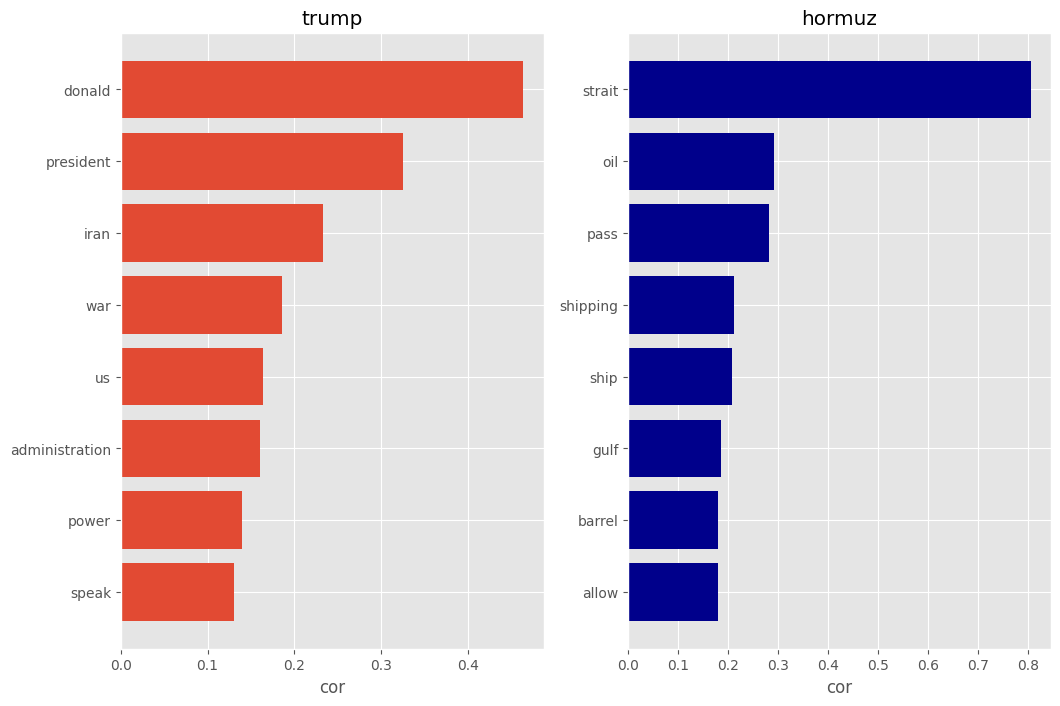

In [ ]:
d_sum = d_sum.sort_values(by=['cor'])
m_sum = m_sum.sort_values(by=['cor'])

plt.figure(figsize=(12,8))   # 顯示圖框架大小 (寬,高)
plt.style.use("ggplot")     # 使用ggplot主題樣式
# plt.rcParams['font.sans-serif']=['SimHei'] #使中文能正常顯示

plt.subplot(121)
plt.title('trump')
plt.xlabel('cor')
plt.barh(d_sum['word2'],d_sum['cor'])

plt.subplot(122)
plt.title('hormuz')
plt.xlabel('cor')
plt.barh(m_sum['word2'],m_sum['cor'],color="darkblue")


plt.show()

此圖顯示特定詞彙的相關詞關係。

* 「trump」主要與 donald、president、iran、war、us 等詞相關，代表其與政治人物身份及美伊衝突密切相關。

* 「hormuz」則與 strait、oil、shipping、ship 等詞相關，顯示其主要與石油運輸及航運議題有關。

整體而言，不同關鍵詞代表不同主題：

* trump → 政治與戰爭
* hormuz → 能源與地理

# 6.計算章節相似度


本研究利用 TF-IDF 向量計算文章之間的 cosine similarity（餘弦相似度），用來衡量不同新聞之間的內容相似程度。

相似度數值介於 0 到 1 之間：

* 越接近 1：兩篇文章內容越相似
* 越接近 0：兩篇文章內容差異越大

In [ ]:
data_cos = data_cor.copy()
data_cos.head()

,system_id,artTitle,artDate,artUrl,artContent,sentence,word
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,Iran has effectively blocked the Strait of Hormuz,IRAN effectively block strait hormuz
1,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,one of the world s busiest oil shipping channels,world busy oil shipping channel
2,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,since the US and Israel attacked the country o...,US ISRAEL attack february world oil liquefy na...
3,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,the corridor only about km miles wide at its e...,corridor km mile wide entrance exit
4,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,Iran has effectively blocked the Strait of Hor...,and about km wide at its narrowest point conne...,km wide narrow point connect gulf arabian sea ...


In [ ]:
# Bag of Word
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data_cos["word"])
vocabulary = vectorizer.get_feature_names_out()
# 轉成dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df.head()

,abbas,abbasabad,abdullah,abhishek,ability,able,aboard,aboutsecurity,aboutwhenthe,abroad,...,youth,youtube,yugoslavia,yuna,yvette,zahra,zakani,zamir,zayed,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
transformer = TfidfTransformer()
# print(transformer)
# 將詞頻矩陣X統計成TF-IDF值
tfidf = transformer.fit_transform(X)
# print(tfidf.toarray())

# 轉成dataframe
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf.toarray())
TFIDF_df.head()

,abbas,abbasabad,abdullah,abhishek,ability,able,aboard,aboutsecurity,aboutwhenthe,abroad,...,youth,youtube,yugoslavia,yuna,yvette,zahra,zakani,zamir,zayed,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


計算章節間的cosine similarity

In [ ]:
cosine_matrix = cosine_similarity(tfidf.toarray(), tfidf.toarray())

找和第一篇報導(https://www.bbc.com/news/articles/c78n6p09pzno) 相似的其他新聞

In [ ]:
cos_df = pd.DataFrame(cosine_matrix[1], columns = ['cos_similarity'])
cos_df

,cos_similarity
0,0.115908
1,1.000000
2,0.104112
3,0.040419
4,0.066557
5,0.069176
6,0.035997
7,0.075341
8,0.120567
9,0.108157


本研究利用 cosine similarity 計算句子之間的相似度，並找出與指定句子最相似的句子。

從結果可以觀察到：

- 相似度為 **1.0** 的句子為原句本身，代表完全相同  
- 相似度約 **0.6** 的句子，多與「全球最繁忙的石油運輸路線」相關  
- 相似度約 **0.2** 的句子，則與「航運、荷姆茲海峽及國際影響」有關  

In [ ]:
cos_df = (
    pd.DataFrame(cosine_matrix[1], columns=['cos_similarity'])
    .reset_index(drop=True)
    .merge(
        data_cos.reset_index(drop=True),
        how='inner',
        left_index=True,
        right_index=True
    )
)

result = (
    cos_df.loc[:, ["cos_similarity", "system_id", "sentence"]]
    .sort_values(by='cos_similarity', ascending=False)
    .head(10)
)

result

,cos_similarity,system_id,sentence
1,1.000000,30,one of the world s busiest oil shipping channels
26,0.195214,30,with Iran threatening to attack tankers and ot...
18,0.169722,30,which is then turned back into gas at its dest...
15,0.152319,30,according to the US government
19,0.141671,30,cooking and power Hormuz is also a crucial rou...
22,0.140003,30,including food
43,0.132098,30,including Iran
29,0.127586,30,the BBC had been able to verify attacks on com...
8,0.120567,30,according to estimates from the US Energy Info...
0,0.115908,30,Iran has effectively blocked the Strait of Hormuz


# 7.建立Ngram預測模型


建立 N-gram 預測模型，用來根據前面的詞彙，預測下一個可能出現的詞。

In [ ]:
data2 = sentence_df.copy()
sen_tokens = data2['sentence'].apply(getToken).tolist()
sen_tokens[0]

['IRAN', 'effectively', 'block', 'strait', 'hormuz']

In [ ]:
def ngram(documents, N=2):
    ngram_prediction = dict()
    total_grams = list()
    words = list()
    Word = namedtuple('Word', ['word', 'prob'])

    for doc in documents:
        # 加上開頭和結尾 tag
        split_words = ['<s>'] + list(doc) + ['</s>']
        # 計算分子
        [total_grams.append(tuple(split_words[i:i+N])) for i in range(len(split_words)-N+1)]
        # 計算分母
        [words.append(tuple(split_words[i:i+N-1])) for i in range(len(split_words)-N+2)]

    total_word_counter = Counter(total_grams)
    word_counter = Counter(words)

    for key in total_word_counter:
        word = ''.join(key[:N-1])
        if word not in ngram_prediction:
            ngram_prediction.update({word: set()})

        next_word_prob = total_word_counter[key]/word_counter[key[:N-1]] #P(B|A)
        w = Word(key[-1], '{:.3g}'.format(next_word_prob))
        ngram_prediction[word].add(w)

    return ngram_prediction

In [ ]:
# Bigram預測模型為例
bi_prediction = ngram(sen_tokens, N=2)

預測下一個出現的詞

In [ ]:
text = 'trump'
next_words = list(bi_prediction[text])
next_words.sort(key = lambda s: s[1], reverse = True)
for next_word in next_words[:5]:
    print('next word: {}, probability: {}'.format(next_word.word, next_word.prob))

next word: say, probability: 0.129
next word: </s>, probability: 0.0693
next word: administration, probability: 0.0347
next word: IRAN, probability: 0.0198
next word: call, probability: 0.0198


**當輸入詞為「trump」時，模型預測的下一個詞包括：**

- 「say」為最常出現的接續詞，表示新聞中常出現「Trump said」的句型  
- 出現「administration」、「IRAN」等詞，顯示其與政治與國際議題相關  


In [ ]:
text = 'hormuz'
next_words = list(bi_prediction[text])
next_words.sort(key = lambda s: s[1], reverse = True)
for next_word in next_words[:5]:
    print('next word: {}, probability: {}'.format(next_word.word, next_word.prob))

next word: </s>, probability: 0.247
next word: IRAN, probability: 0.039
next word: US, probability: 0.026
next word: gulf, probability: 0.026
next word: narrow, probability: 0.026


**當輸入詞為「hormuz」時，模型預測的下一個詞包括：**

- 「IRAN」顯示荷姆茲海峽與伊朗高度相關  
- 出現「key」、「matter」等詞，表示其在文本中常被描述為重要議題  


In [ ]:
text = 'gas'
next_words = list(bi_prediction[text])
next_words.sort(key = lambda s: s[1], reverse = True)
for next_word in next_words[:5]:
    print('next word: {}, probability: {}'.format(next_word.word, next_word.prob))

next word: field, probability: 0.131
next word: supply, probability: 0.107
next word: facility, probability: 0.0476
next word: lpg, probability: 0.0476
next word: shortage, probability: 0.0357


**當輸入詞為「gas」時，模型預測的下一個詞包括：**

- 「gas field」與「gas supply」為常見詞組，代表天然氣資源與供應問題  
- 「facility」、「lpg」顯示與能源設施與液化天然氣相關  
- 「shortage」則反映供應不足的議題



---


# **1.第七週(字詞分類)**





In [ ]:
import re
from pprint import pprint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jieba
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, KFold, GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    RocCurveDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelBinarizer, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

# **2.資料處理**

從 Google Drive 下載已整理好的四類 BBC 新聞資料（如戰爭、娛樂、經濟與體育），並載入為 DataFrame 以進行後續分析。

In [ ]:
import gdown
import pandas as pd
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords as nltk_stopwords

# 英文 stopwords
stop_words = set(nltk_stopwords.words('english'))

# 手動 stopwords
extra_stopwords = [
    "use", "tell", "make", "take", "see", "go",
    "would", "could", "say", "begin", "add", "follow", "come",
    "one", "two",
    "day", "week", "time", "last", "since", "march",
    "people", "country", "state", "government",
    "report", "include", "also", "official", "post", "verify",
    "long", "across",
    "bbc",
]

# 合併全部 stopwords
all_stopwords = stop_words | set(extra_stopwords)

# 4 個檔案
file_ids = {
    'war': '1v_5BW3DAEbZ4o2Vgh95o5oboIa0HjiBS',
    'ent': '1hAPspIotb2H1SUZQNmW10m7WK95oud_j',
    'economy': '170RJ5-gerOQMFy3dNG5zasN4hqfOEiPs',
    'sport': '1-O5OF7IpEEIW3N_huwxQ8h_WmZc7Lfc3'
}

dataframes = []

for name, file_id in file_ids.items():
    url = f'https://drive.google.com/uc?id={file_id}'
    output = f'{name}.xlsx'

    # 下載
    gdown.download(url, output, quiet=False)

    # 讀取
    df = pd.read_excel(output, engine='openpyxl')

    # 清理欄位
    df.columns = df.columns.str.strip()

    # rename
    df = df.rename(columns={
        'link': 'artUrl',
        'title': 'artTitle',
        'date': 'artDate',
        'content': 'artContent'
    })

    # 刪除欄位
    if 'post_id' in df.columns:
        df = df.drop(columns=['post_id'])

    # 加上 type 欄位
    df['type'] = name

    # stopwords 過濾
    df['artContent'] = df['artContent'].apply(
        lambda text: ' '.join(
            word for word in str(text).lower().split()
            if word not in all_stopwords
        )
    )

    dataframes.append(df)

# 合併成一個 DataFrame
news = pd.concat(dataframes, ignore_index=True)

news.head(1000)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Downloading...
From: https://drive.google.com/uc?id=1v_5BW3DAEbZ4o2Vgh95o5oboIa0HjiBS
To: /content/war.xlsx
100%|██████████| 128k/128k [00:00<00:00, 3.21MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hAPspIotb2H1SUZQNmW10m7WK95oud_j
To: /content/ent.xlsx
100%|██████████| 104k/104k [00:00<00:00, 2.94MB/s]
Downloading...
From: https://drive.google.com/uc?id=170RJ5-gerOQMFy3dNG5zasN4hqfOEiPs
To: /content/economy.xlsx
100%|██████████| 77.0k/77.0k [00:00<00:00, 3.03MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-O5OF7IpEEIW3N_huwxQ8h_WmZc7Lfc3
To: /content/sport.xlsx
100%|██████████| 119k/119k [00:00<00:00, 3.70MB/s]


,system_id,artTitle,artDate,artUrl,artContent,type
0,30,Iran war: What is the Strait of Hormuz and why...,2025-06-23T10:05:17.449Z,https://www.bbc.co.uk/news/articles/c78n6p09pzno,"iran effectively blocked strait hormuz, world'...",war
1,1,Why did US and Israel attack Iran and how long...,2026-02-28T09:03:32.279Z,https://www.bbc.co.uk/news/articles/cx2dyz6p3weo,conflict middle east continues rageafter us is...,war
2,18,US-Israel war with Iran: Mapping strikes acros...,2026-02-28T16:40:48.148Z,https://www.bbc.co.uk/news/articles/c4g0pnnj8xyo,us president donald trump postponed threat str...,war
3,51,Trump warns 'there will likely be more' US dea...,2026-03-01T22:11:12.814Z,https://www.bbc.co.uk/news/videos/cwykxdy4p5lo,video played us president donald trump posted ...,war
4,37,What happened on the third day of the US-Israe...,2026-03-02T23:21:16.888Z,https://www.bbc.co.uk/news/videos/c23zrpvln04o,video played us-israeli war iran entered third...,war
...,...,...,...,...,...,...
212,41,How money is talking as Fitzpatrick turns up v...,2026-04-20T14:14:01.039Z,https://www.bbc.com/sport/articles/cy41k2k1mvgo,video played fitzpatrick beats scheffler play-...,sport
213,42,Record-breaking Bayern win Bundesliga - now fo...,2026-04-19T19:05:10.695Z,https://www.bbc.com/sport/football/articles/cq...,video played bundesliga highlights: bayern mun...,sport
214,43,Find out more about our BBC Sport app,2024-03-26T13:59:30.631Z,https://www.bbc.com/sport/articles/cl5q9dk9jl3o,video played sport app: download latest premie...,sport
215,44,BBC Sport App,2024-08-07T14:16:59.357Z,https://www.bbc.com/sport/articles/cx2gkjzyke4o,video played sport app: download latest premie...,sport


句子切分與清理

In [ ]:
import pandas as pd
import re

# 複製資料
news_df = news.copy()

# 斷句
news_df['sentence'] = news_df['artContent'].str.split(r"[,，。！!？?]+")

# 展開
news_df = news_df.explode('sentence').reset_index(drop=True)

# 清理函式
def clean_english(text):
    if pd.isna(text):
        return ''

    text = str(text)

    # 保護專有名詞
    text = re.sub(r'K-POP', 'KPOP', text, flags=re.IGNORECASE)
    text = re.sub(r'COVID-19', 'COVID19', text, flags=re.IGNORECASE)
    text = re.sub(r'AI-generated', 'AIgenerated', text, flags=re.IGNORECASE)

    # 只保留英文字母
    text = re.sub('[^A-Za-z]+', ' ', text)

    # 轉小寫（NLP標準）
    text = text.lower()

    return text.strip()

# 套用清理
news_df['sentence'] = news_df['sentence'].apply(clean_english)

# 移除空句
news_df = news_df[news_df['sentence'] != '']

# 移除單字句
news_df = news_df[news_df['sentence'].str.split().str.len() > 1]

# 過濾雜訊
news_df = news_df[
    ~news_df['sentence'].str.contains(
        'video can not be played|bbc sounds',
        case=False,
        na=False
    )
]

# 查看結果（保留 type）
news_df[['sentence', 'type']].head(10)

,sentence,type
0,iran effectively blocked strait hormuz,war
1,world s busiest oil shipping channels,war
2,us israel attacked february world s oil liquef...,war
3,corridor km miles wide entrance exit,war
4,km wide narrowest point connects gulf arabian ...,war
5,used major middle eastern oil lng producers,war
6,well customers,war
7,million barrels oil oil products passed strait...,war
8,according estimates us energy information admi...,war
11,saudi arabia uae global lng shipped strait,war


統計各類新聞的斷句數量


*   戰爭類(war):2101
*   娛樂類(ent):2353
*   經濟類(economy):1394
*   體育類(sport):2273

In [ ]:
news_df['type'].value_counts()

,count
type,
ent,2353
sport,2273
war,2101
economy,1394


# **3.分類模型的訓練流程**

## 3.1.根據7:3的比例切分資料集


利用 sklearn 中的 train_test_split 函數將 raw_data 隨機切7:3，並設置 random_state 讓每次切分的結果一致。



In [ ]:
data = news_df.copy()
X = data["sentence"]
y = data["type"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)

X_train.head()

,sentence
4685,year s grammy awards bts mania swept globe rec...
1810,per various brokerages given comes backdrop re...
1397,three charts warning signs flashing trump iran...
320,us administrations relied aumf passed septembe...
5983,reserves oil gas rapidly become uneconomical e...


* 約69% 訓練集( y_train )
* 約30% 測試集( y_test )


In [ ]:
print(len(X_train) / len(X))
print(len(X_test) / len(X))

0.6999138037187539
0.30008619628124616


In [ ]:
y_train.head()

,type
4685,ent
1810,war
1397,war
320,war
5983,economy


In [ ]:
# 看一下各個資料集切分的比例，應該要一致
print(
    f"raw data percentage :\n{data['type'].value_counts(normalize=True) * 100}"
)
print(f"\ntrain percentage :\n{y_train.value_counts(normalize=True) * 100}")
print(f"\ntest percentage :\n{y_test.value_counts(normalize=True) * 100}")

raw data percentage :
type
ent        28.974264
sport      27.989164
war        25.871198
economy    17.165374
Name: proportion, dtype: float64

train percentage :
type
ent        29.152006
sport      28.114004
war        25.897255
economy    16.836735
Name: proportion, dtype: float64

test percentage :
type
ent        28.559705
sport      27.697989
war        25.810423
economy    17.931883
Name: proportion, dtype: float64


## 3.2.將文章轉為 DTM

將文字轉換為數值向量（Bag-of-Words），以便模型進行運算與分類分析。

* 每個字詞變成一個特徵
* 取最常出現、最重要的 1000 個字

In [ ]:
# vectorizer
vectorizer = CountVectorizer(max_features=1000, stop_words="english")
vectorizer.fit(X_train)
vec_train = vectorizer.transform(X_train)
vec_test = vectorizer.transform(X_test)

# classifier
clf = LogisticRegression()
clf.fit(vec_train, y_train)

y_pred = clf.predict(vec_test)
y_pred_proba = clf.predict_proba(vec_test)

**本模型整體準確率為 76%，顯示其具備良好的分類能力。**

其中娛樂類（ent）表現最佳（F1-score = 0.80），而經濟類（economy）表現相對較弱（F1-score = 0.74）。

In [ ]:
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     economy       0.81      0.68      0.74       437
         ent       0.86      0.75      0.80       696
       sport       0.68      0.88      0.77       675
         war       0.77      0.73      0.75       629

    accuracy                           0.76      2437
   macro avg       0.78      0.76      0.76      2437
weighted avg       0.78      0.76      0.76      2437



## 3.3.混淆矩陣

橫軸（Pred）代表模型預測類別，縱軸（True）代表實際類別，透過矩陣形式呈現分類結果的分布情形。

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, 'economy'),
  Text(0, 1.5, 'ent'),
  Text(0, 2.5, 'sport'),
  Text(0, 3.5, 'war')])

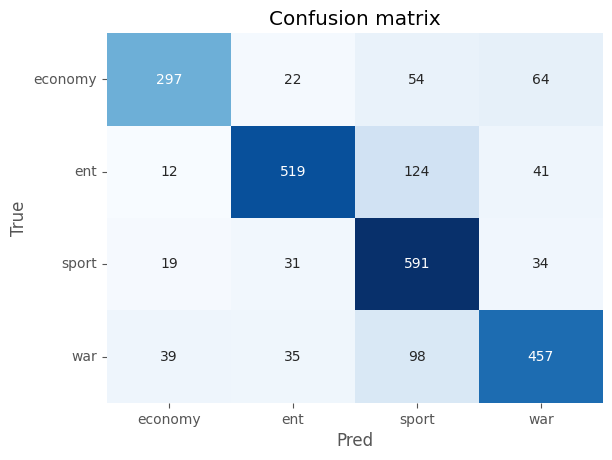

In [ ]:
classes = clf.classes_
cm = confusion_matrix(y_test, y_pred)
## Plot confusion matrix
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)
ax.set(
    xlabel="Pred",
    ylabel="True",
    xticklabels=classes,
    yticklabels=classes,
    title="Confusion matrix",
)
plt.yticks(rotation=0)

由混淆矩陣可觀察到，模型在體育（sport）與娛樂（ent）類別具有較高的辨識能力，而經濟（economy）與戰爭（war）類別則較易發生誤判，特別是 war 與 sport 之間的混淆較為明顯。此現象可能源於不同類別之間存在相似詞彙，導致模型在判斷時產生混淆。

**可能原因是「用詞很像」，例如：**

* war / economy → oil、market、government
* war / sport → team、win、attack（語意可能重疊）

## 3.4.TF-IDF

用 TF-IDF 取代原本的詞頻方法，重新訓練分類模型。

In [ ]:
vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
vec_train = vectorizer.fit_transform(X_train)
vec_test = vectorizer.transform(X_test)

clf.fit(vec_train, y_train)
y_pred = clf.predict(vec_test)
y_pred_proba = clf.predict_proba(vec_test)

# results
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     economy       0.84      0.69      0.76       437
         ent       0.86      0.74      0.80       696
       sport       0.69      0.89      0.78       675
         war       0.78      0.74      0.76       629

    accuracy                           0.78      2437
   macro avg       0.79      0.77      0.77      2437
weighted avg       0.79      0.78      0.78      2437



採用 TF-IDF 作為文字向量化方法後，**模型整體準確率由 0.76 提升至 0.78**，顯示其在特徵表達上優於單純詞頻方法。各類別之 F1-score 亦略有提升，模型表現更為穩定，顯示 TF-IDF 能有效強化關鍵詞的辨識能力。

## 3.5.Cross Validation

本研究採用 5-fold 交叉驗證評估模型穩定性，**結果顯示整體準確率約為 0.75，與先前測試結果相近**，顯示模型具備良好的泛化能力。各類別中以娛樂（ent）表現最佳，而經濟（economy）相對較弱。整體而言，模型在不同資料切分下表現一致，具備穩定性與可靠性。

***交叉驗證顯示模型表現穩定，沒有過度依賴特定資料切分。***

              precision    recall  f1-score   support

     economy       0.80      0.65      0.71       957
         ent       0.83      0.74      0.79      1657
       sport       0.67      0.85      0.75      1598
         war       0.76      0.72      0.74      1472

    accuracy                           0.75      5684
   macro avg       0.76      0.74      0.75      5684
weighted avg       0.76      0.75      0.75      5684



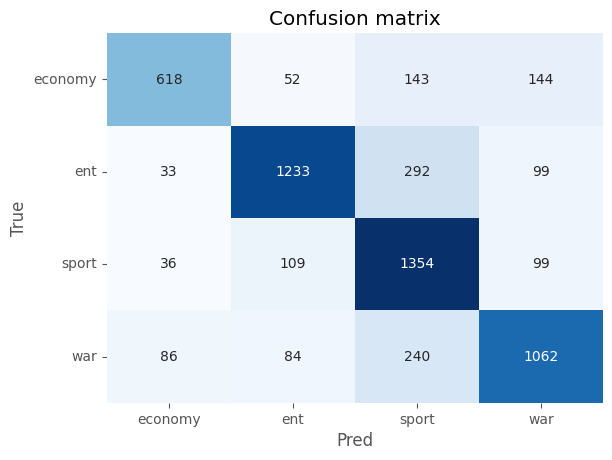

In [ ]:
# 定義模型訓練組合
## pipeline: 資料處理 vectorizer + 分類器 clf
## 由於 cross-validation 會自動將資料分成 train/test，因此 input 只要給 X, y 即可

def train_cv(vectorizer, clf, X, y):

    ## train classifier
    vec_X = vectorizer.fit_transform(X).toarray()

    ## get cv results
    cv_results = cross_validate(clf, vec_X, y, cv=5, return_estimator=True)
    y_pred = cross_val_predict(clf, vec_X, y, cv=5)
    y_pred_proba = cross_val_predict(clf, vec_X, y, cv=5, method="predict_proba")

    # one-hot encoding
    enc = OneHotEncoder(sparse_output=False)
    enc.fit(y.values.reshape(-1, 1))

    ## Accuracy, Precision, Recall, F1-score
    cls_report = classification_report(y, y_pred, output_dict=True)
    print(classification_report(y, y_pred))

    classes = cv_results['estimator'][0].classes_

    ## Plot confusion matrix
    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)
    ax.set(
        xlabel="Pred",
        ylabel="True",
        xticklabels=classes,
        yticklabels=classes,
        title="Confusion matrix",
    )
    plt.yticks(rotation=0)

    clf.fit(vec_X, y)
    # return the model object
    return cls_report, clf

vectorizer = CountVectorizer(max_features=1000, stop_words="english")
clf = LogisticRegression()
result = train_cv(vectorizer, clf, X_train, y_train)

# **4.比較不同模型的效果**

本研究比較多種分類模型之表現，結果顯示 Logistic Regression 在整體準確率（0.75）及各類別 F1-score 上皆具有最佳且穩定的表現。相較之下，Decision Tree 表現較差（Accuracy = 0.68），而 SVM 與 Random Forest 則呈現中等水準。綜合評估後，Logistic Regression 為本研究最適合之分類模型。

**5-fold 交叉驗證各模型 Accuracy :**
* 邏輯迴歸（Logistic Regression）：0.75
* 決策樹（Decision Tree）：0.68
* 支援向量機（SVM）：0.73
* 隨機森林（Random Forest）：0.72

now training: clf_logistic
              precision    recall  f1-score   support

     economy       0.80      0.65      0.71       957
         ent       0.83      0.74      0.79      1657
       sport       0.67      0.85      0.75      1598
         war       0.76      0.72      0.74      1472

    accuracy                           0.75      5684
   macro avg       0.76      0.74      0.75      5684
weighted avg       0.76      0.75      0.75      5684

now training: clf_dtree
              precision    recall  f1-score   support

     economy       0.58      0.65      0.62       957
         ent       0.76      0.72      0.74      1657
       sport       0.64      0.71      0.67      1598
         war       0.70      0.61      0.65      1472

    accuracy                           0.68      5684
   macro avg       0.67      0.67      0.67      5684
weighted avg       0.68      0.68      0.68      5684

now training: clf_svm
              precision    recall  f1-score   support

  

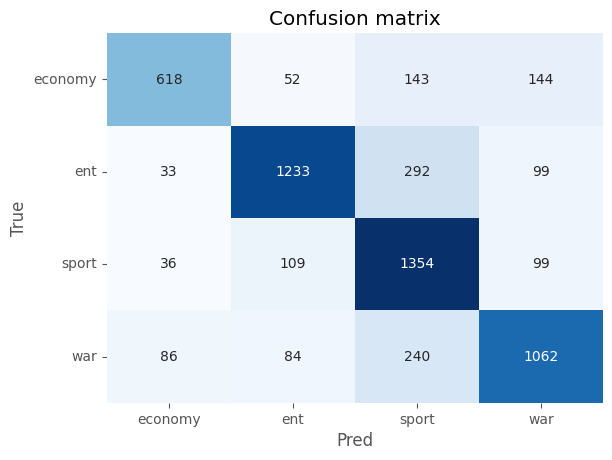

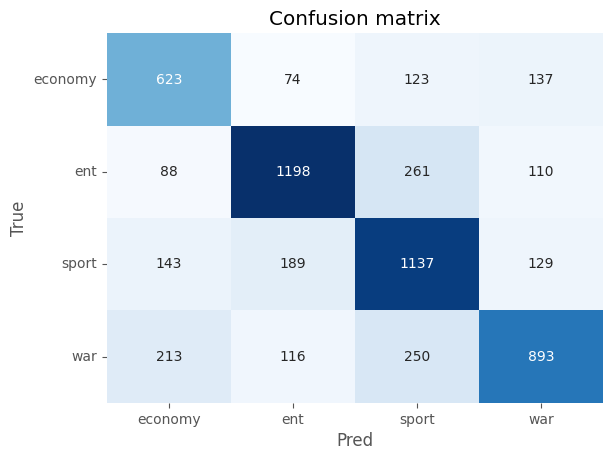

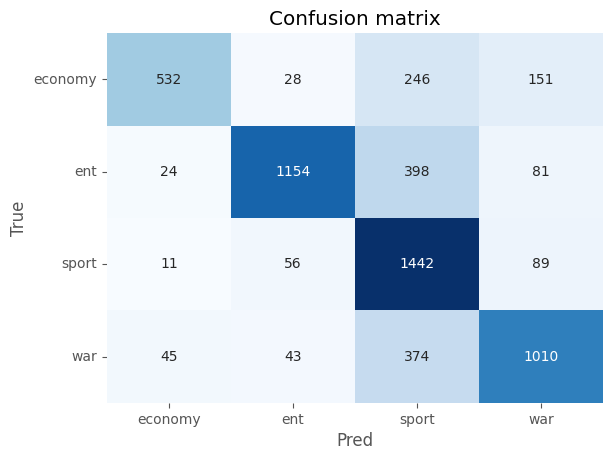

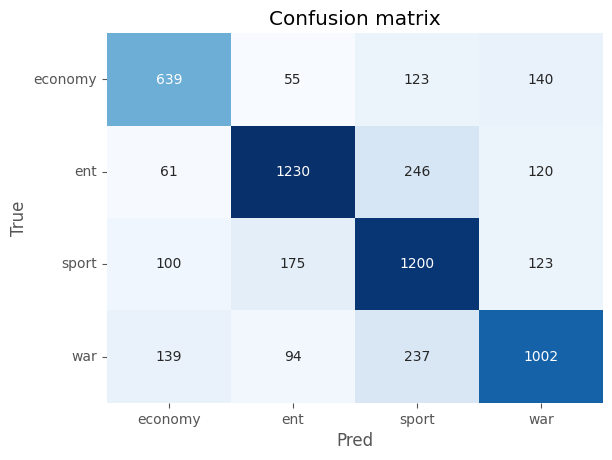

In [ ]:
# 準備訓練資料
X = data["sentence"]
y = data["type"]
# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)
# 定義模型訓練組合
model_set = dict()
model_set['clf_logistic'] = LogisticRegression()
model_set['clf_dtree'] = DecisionTreeClassifier()
model_set['clf_svm'] = svm.SVC(probability=True) # 要使用SVM的predict_proba的話，必須在叫出SVC的時候就將probability設為True
model_set['clf_rf'] = RandomForestClassifier()
# 定義 vectorizer
vectorizer = CountVectorizer(max_features=1000, stop_words="english")
# 存結果
result_set = dict()

for k, model in model_set.items():
    print("="*100)
    print(f"now training: {k}")
    result_set[k], model_set[k] = train_cv(vectorizer, model, X_train, y_train)
    print("="*100)

從算好的結果中，選出 F1-score 最大的模型

In [ ]:
max = 0
best_model_name = ""
best_model_metric = "f1-score"

## choose max f1-score model from result_set
for k, v in result_set.items():
    if v['weighted avg'][best_model_metric] > max:
        max = v['weighted avg'][best_model_metric]
        best_model_name = k
print(f"best model: {best_model_name}")

best model: clf_logistic


經比較各模型之表現後，邏輯迴歸模型（Logistic Regression）為本研究中表現最佳之分類模型。

In [ ]:
y_pred = model_set['clf_logistic'].predict(vectorizer.transform(X_test))
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     economy       0.81      0.68      0.74       437
         ent       0.86      0.75      0.80       696
       sport       0.68      0.88      0.77       675
         war       0.77      0.73      0.75       629

    accuracy                           0.76      2437
   macro avg       0.78      0.76      0.76      2437
weighted avg       0.78      0.76      0.76      2437



# **5.分析可解釋模型的結果**

本研究透過分析 Logistic Regression 模型之特徵權重，找出各類別中具有代表性的關鍵詞。結果顯示，不同類別具有明顯區分的詞彙特徵，模型可依據這些關鍵詞進行分類判斷，提升模型之可解釋性。

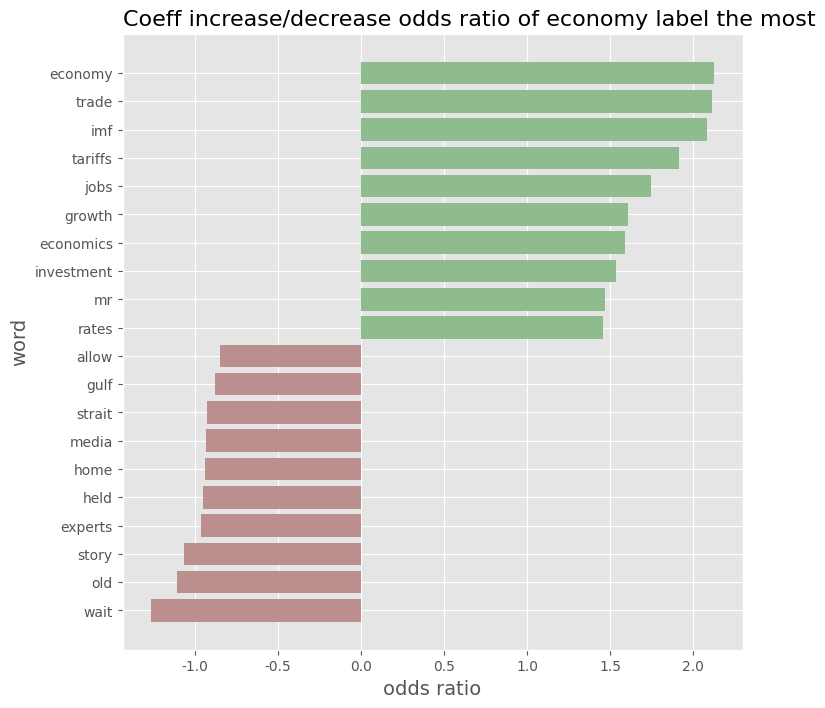

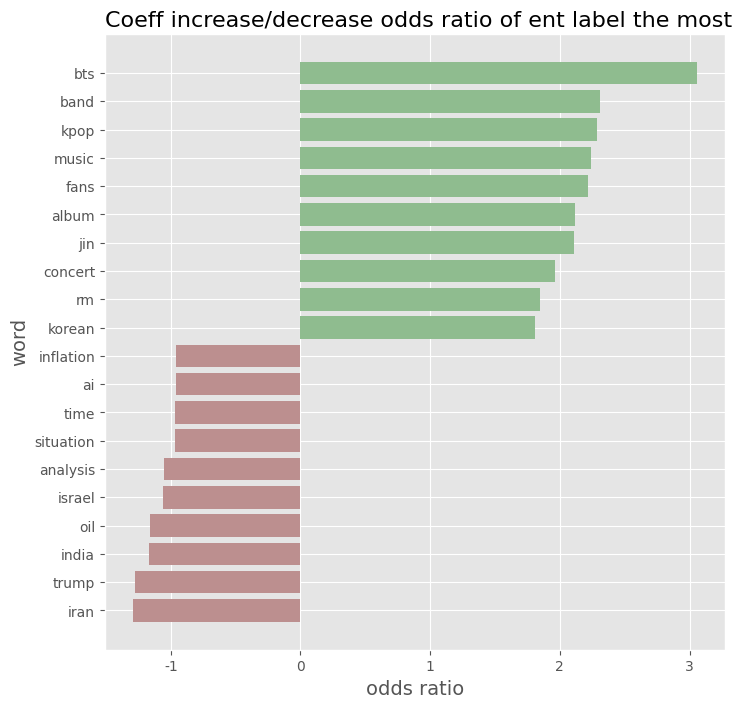

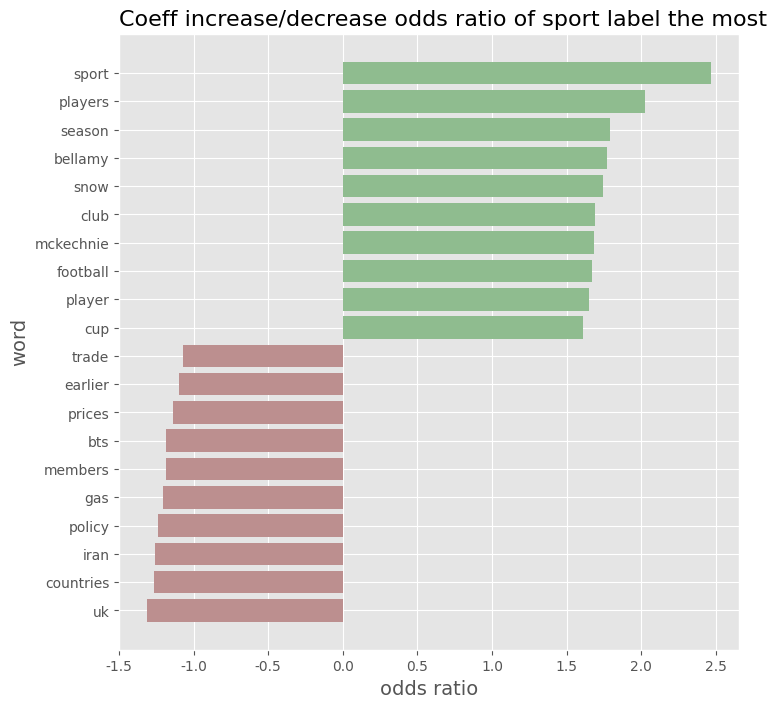

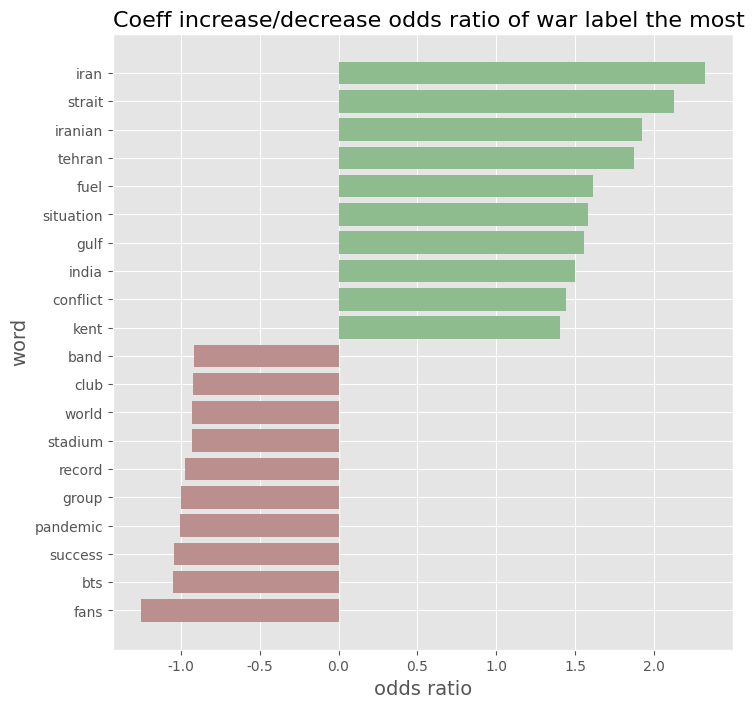

In [ ]:
def plot_coef(logistic_reg_model, feature_names, top_n=10):
    # 選出某個類別的前10大影響力字詞
    log_odds = logistic_reg_model.coef_.T
    coef_df = pd.DataFrame(
        log_odds,
        columns=logistic_reg_model.classes_, index=feature_names
    )
    for label in coef_df.columns:
        select_words = (
            coef_df[[label]]
            .sort_values(by=label, ascending=False)
            .iloc[np.r_[0:top_n, -top_n:0]]
        )
        word = select_words.index
        count = select_words[label]
        category_colors = np.where(
            select_words[label] >= 0, "darkseagreen", "rosybrown"
        )  # 設定顏色

        fig, ax = plt.subplots(figsize=(8, top_n*0.8))  # 設定畫布
        plt.rcParams["axes.unicode_minus"] = False

        ax.barh(word, count, color=category_colors)
        ax.invert_yaxis()
        ax.set_title(
            "Coeff increase/decrease odds ratio of " + label + " label the most",
            loc="left",
            size=16,
        )
        ax.set_ylabel("word", size=14)
        ax.set_xlabel("odds ratio", size=14)

# plot logistic model
plot_coef(logistic_reg_model=model_set['clf_logistic'], feature_names=vectorizer.get_feature_names_out(), top_n=10)

* 在經濟類（economy）中，模型主要依據與貿易及經濟指標相關的詞彙進行判斷，例如 trade、tariffs、growth、investment 與 rates 等，顯示此類新聞多聚焦於經濟活動與市場變化；而如 gulf、strait 等詞則較不屬於經濟類，反而偏向戰爭相關內容。

* 在娛樂類（ent）中，模型主要依據與音樂及藝人相關的詞彙，如 bts、kpop、music、album 與 concert 等進行分類，顯示娛樂新聞多與流行文化及藝人活動有關；相對地，iran、oil、inflation 等詞則較少出現在娛樂類中，偏向政治或經濟議題。

* 在體育類（sport）中，關鍵詞集中於比賽與球隊相關內容，例如 players、season、football、club 與 cup 等，顯示模型能有效捕捉體育新聞的語意特徵；而 trade、gas、policy 等詞則較不屬於體育類，通常出現在經濟或政治新聞中。

* 在戰爭類（war）中，模型主要依據與地緣政治及衝突相關的詞彙進行判斷，如 iran、strait、conflict、tehran 與 fuel 等，顯示該類新聞多涉及國際衝突與能源議題；而 stadium、fans、bts 等詞則明顯屬於體育或娛樂領域，因此對戰爭類具有負向影響。

# 1.第九週(主題模型)

# 2.資料前處理

第6週已完成文本斷詞連接並建立 (war_df) ，本節將其複製為 (text_df) 以進行後續分析。

In [ ]:
text_df = war_df.copy()
text_df.head(10)

,system_id,text
0,1,conflict middle east continue rageafter US ISR...
1,2,hiring US surge month despite energy shock unc...
2,3,without set timeline end conflict primetime ad...
3,4,primetime televise speech white house roughly ...
4,5,american farmer face intense financial pressur...
5,6,control tower adolfo suarez airport madrid spa...
6,7,member IRAN volunteer militia basij attend teh...
7,8,military expert scale spread damage observe re...
8,9,minister join european union foreign policy ch...
9,10,fuel tom collins tractor double price IRAN war...


計算文章總數

In [ ]:
text_df['text'] = text_df['text'].str.lower()
# 去除掉停用字之後轉換成List儲存
docs = [[word for word in doc.split() if word not in stop_words] for doc in text_df['text']]
# 總共有47篇報導

# 3.LDA模型訓練資料轉換

安裝套件

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.3 MB/s eta 0:00:00


匯入套件
* Phrases：建立詞組（bigram）
* Dictionary：建立詞彙字典
* LdaModel：LDA主題模型
* CoherenceModel：評估主題品質
* corpus2csc：轉換矩陣格式

In [ ]:
from gensim.models import Phrases
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.matutils import corpus2csc

## 3.1.建立 bigram 詞組模型

首先透過 bigram 模型擷取常見詞組，以提升語意表達能力

In [ ]:
# 建立一個 bigram 模型，找出出現次數大於20次的bigram
bigram = Phrases(docs, min_count=20)
for idx in range(len(docs)):
    for token in bigram[docs[idx]]:
        if '_' in token:
            # 將Token (bigram) 加入到docs裡面
            docs[idx].append(token)

## 3.2.建立 Dictionary字典

接著建立詞彙字典（Dictionary），將詞語轉換為編號；最後透過 Bag-of-Words 方法建立語料（Corpus），將文本轉換為詞頻向量，作為後續主題模型訓練之輸入。

In [ ]:
# 建立 docs 的 dictionary物件
dictionary = Dictionary(docs)
print(dictionary)

# Bag-of-words representation of the documents.
# 用 gensim ldamodel input 需要將文章轉換成 bag of words
corpus = [dictionary.doc2bow(doc) for doc in docs]

Dictionary<4397 unique tokens: ['ability', 'access', 'accord', 'accounting', 'accuse']...>


## 3.3.訓練 LDA topic model

匯入套件

In [ ]:
import time

In [ ]:
t0 = time.time()

topic_num_list = np.arange(2, 16)
result = {"topic_num":[], "perplexity":[], "pmi":[]}
model_set = dict()


for topic_num in topic_num_list:
    # 根據不同topic_num訓練LDA模型
    model = LdaModel(
        corpus = corpus,
        num_topics = topic_num ,
        id2word=dictionary,
        random_state = 1500,
        passes=5
        )

    loss = model.log_perplexity(corpus)
    # 計算Perplexity和PMI值
    pmi = CoherenceModel(model=model, texts=docs, coherence='c_npmi').get_coherence()
    perplexity = np.exp(-1. * loss)

    # 將結果儲存起來
    result['topic_num'].append(topic_num)
    result['perplexity'].append(perplexity)
    result['pmi'].append(pmi)

print(f"花費時間: {time.time() - t0} sec")

花費時間: 18.140189170837402 sec


## 3.4.視覺化Perplexity 和 PMI 評估主題模型表現

本研究透過 Perplexity 與 PMI 指標評估不同主題數之模型表現。**結果顯示，Perplexity 在主題數為3時較低，而 PMI 則在主題數為 5 時達到最佳表現。**

In [ ]:
result = pd.DataFrame(result)
result

,topic_num,perplexity,pmi
0,2,2022.783953,-0.075487
1,3,1966.710054,-0.077465
2,4,2017.610275,-0.100156
3,5,2096.910797,-0.046434
4,6,2145.810911,-0.058424
5,7,2200.484302,-0.075117
6,8,2127.373836,-0.080355
7,9,2224.718807,-0.087367
8,10,2285.095501,-0.081044
9,11,2344.557213,-0.096472


**Perplexity(困惑度):** 越低越好，最低點：約在 topic = 3

<Axes: xlabel='topic_num'>

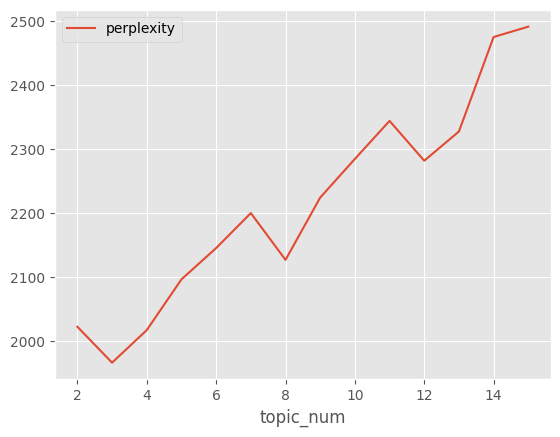

In [ ]:
result.plot.line(x='topic_num', y='perplexity')

**PMI / coherence（語意一致性）:** 越高越好，最佳點：約在 topic = 5

<Axes: xlabel='topic_num'>

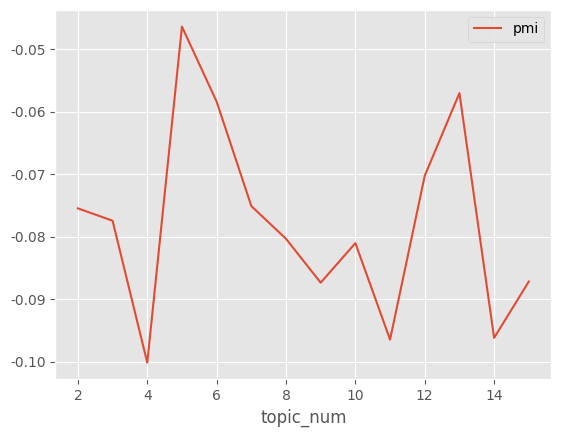

In [ ]:
result.plot.line(x='topic_num', y='pmi')

## 3.5.LDAvis視覺化結果

用困惑度與語意一致性來評估主題模型好壞，並選擇最佳主題數。

安裝 pyLDAvis 套件，用來「視覺化主題模型（Topic Modeling）」的結果

In [ ]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 9.5 MB/s eta 0:00:00


載入「視覺化 LDA 主題模型」的工具

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 3.5.1 分三個主題

In [ ]:
model3 = LdaModel(
    corpus = corpus,
    num_topics = 3, #修改分組
    id2word=dictionary,
    random_state = 1500,
    passes=5
    )

本研究透過 LDA 主題模型將新聞文本分為三個主要主題。
* Topic 1 為主要主題（占比 65.8%），以國際政治與軍事衝突為核心。關鍵詞：iran、trump、war、israel、attack、military
* Topic 2（31.9%）則聚焦於石油與能源經濟議題。關鍵詞：oil、price、gas、fuel、strait、hormuz
* Topic 3（2.4%）則反映戰爭對民生與經濟之影響。關鍵詞：travel、price、fuel、air

**整體而言，主題間具有明顯區隔性，但亦呈現戰爭與能源議題之間的高度關聯性。**

BBC在報導美伊衝突時，內容主要圍繞在戰爭事件本身、能源市場影響，以及政治決策三個面向，
同時也說明媒體在呈現國際衝突時，並非單一敘事，而是結合多個議題共同構成。

In [ ]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(model3, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.062138 -0.051035       1        1  65.757230
2     -0.078978 -0.024127       2        1  31.860082
0      0.016840  0.075161       3        1   2.382688, topic_info=           Term        Freq       Total Category  logprob  loglift
218       india   94.000000   94.000000  Default  30.0000  30.0000
482          us  341.000000  341.000000  Default  29.0000  29.0000
55         base   75.000000   75.000000  Default  28.0000  28.0000
353       price  110.000000  110.000000  Default  27.0000  27.0000
313         oil  121.000000  121.000000  Default  26.0000  26.0000
...         ...         ...         ...      ...      ...      ...
320   operation    0.871754   30.469565   Topic3  -6.4297   0.1830
790        fuel    0.894704   54.526575   Topic3  -6.4037  -0.3730
470       trump    0.926354  188.479207   Topic3  -6.3689  -1.5785
1157       live    0.869908   30.661283   Topic3  -6.4318   0.1746
353       price    0.902467  110.825364   Topic3  -6.3951  -1.0736

[238 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
2         1  0.486360       accord
2         2  0.509520       accord
1488      1  0.940131      account
1488      2  0.067152      account
7         1  0.886263       action
...     ...       ...          ...
616       1  0.953925  white_house
616       2  0.039747  white_house
2156      2  0.835960       winter
618       1  0.426144         year
618       2  0.559314         year

[340 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 1])

### 3.5.2 分四個主題

In [ ]:
model = LdaModel(
    corpus = corpus,
    num_topics = 4,
    id2word=dictionary,
    random_state = 1500,
    passes=5
    )

本研究透過 LDA 主題模型將新聞文本分為四個主要主題。
* Topic 1 為主要主題（占比 54.5%），以國際政治與軍事衝突為核心。關鍵詞：iran、trump、war、israel、attack、military
* Topic 2（31.1%）則聚焦於石油與能源經濟議題。關鍵詞：oil、price、gas、fuel、strait、hormuz
* Topic 3（12.1%）主要描述軍事行動與戰爭細節。關鍵詞：strike、attack、air、drone、damage
* Topic 4（2.4%）則反映戰爭對民生與經濟之影響。關鍵詞：travel、price、fuel、air

**整體而言，主題間具有明顯區隔性，但亦呈現戰爭與能源議題之間的高度關聯性。**

BBC在報導美伊衝突時，內容主要圍繞在戰爭事件本身、能源市場影響，以及政治決策三個面向，
同時也說明媒體在呈現國際衝突時，並非單一敘事，而是結合多個議題共同構成。

In [ ]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(model, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.085646 -0.049129       1        1  54.495521
2     -0.019333  0.088761       2        1  31.065530
3      0.043338  0.002664       3        1  12.063490
0      0.061641 -0.042296       4        1   2.375459, topic_info=       Term        Freq       Total Category  logprob  loglift
218   india   97.000000   97.000000  Default  30.0000  30.0000
482      us  338.000000  338.000000  Default  29.0000  29.0000
55     base   71.000000   71.000000  Default  28.0000  28.0000
353   price  114.000000  114.000000  Default  27.0000  27.0000
313     oil  122.000000  122.000000  Default  26.0000  26.0000
...     ...         ...         ...      ...      ...      ...
353   price    1.430637  114.348500   Topic4  -5.9313  -0.6412
790    fuel    1.113774   57.426263   Topic4  -6.1816  -0.2028
570   month    1.017601   29.345313   Topic4  -6.2719   0.3783
17      air    1.014500   39.828583   Topic4  -6.2750   0.0698
1253  cause    1.004120   23.988084   Topic4  -6.2853   0.5665

[314 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
2         1  0.366299   accord
2         2  0.572343   accord
2         3  0.068681   accord
1488      1  0.604269  account
1488      3  0.377668  account
...     ...       ...      ...
2156      2  0.930267   winter
618       1  0.294253     year
618       2  0.508255     year
618       3  0.160502     year
618       4  0.026750     year

[511 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 4, 1])

### 3.5.3 分五個主題

In [ ]:
model5 = LdaModel(
    corpus = corpus,
    num_topics = 5, #修改分組
    id2word=dictionary,
    random_state = 1500,
    passes=5
    )

In [ ]:
pyLDAvis.enable_notebook()
p5 = pyLDAvis.gensim_models.prepare(model5, corpus, dictionary)
p5

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.006982 -0.090090       1        1  44.249384
4     -0.020977 -0.058729       2        1  29.717424
2     -0.102474  0.067619       3        1  21.995951
3      0.047855  0.047146       4        1   2.282141
0      0.082578  0.034054       5        1   1.755099, topic_info=        Term        Freq       Total Category  logprob  loglift
482       us  338.000000  338.000000  Default  30.0000  30.0000
55      base   73.000000   73.000000  Default  29.0000  29.0000
470    trump  184.000000  184.000000  Default  28.0000  28.0000
353    price  112.000000  112.000000  Default  27.0000  27.0000
229     iran  566.000000  566.000000  Default  26.0000  26.0000
..       ...         ...         ...      ...      ...      ...
497     well    0.823568   26.589696   Topic5  -6.1808   0.5680
798    speak    0.790534   22.926248   Topic5  -6.2218   0.6753
488      war    0.949291  224.515549   Topic5  -6.0388  -1.4233
289  missile    0.826124   61.188933   Topic5  -6.1777  -0.2623
55      base    0.812736   73.215399   Topic5  -6.1941  -0.4581

[380 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
1346      3  0.917034     absorb
2         1  0.275057     accord
2         2  0.320900     accord
2         3  0.389665     accord
7         1  0.817834     action
...     ...       ...        ...
618       1  0.210062       year
618       2  0.446381       year
618       3  0.315093       year
618       4  0.026258       year
2954      2  0.742230  yesterday

[611 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 5, 3, 4, 1])

# 4.分析每篇報到主題的分佈情況

本研究透過 LDA 模型計算每篇文章之主題分布，並將結果轉換為矩陣形式（theta matrix）。其中，每一列代表一篇文章，每一欄代表一個主題，其數值表示該文章在該主題下的機率分布。此方法可用於分析文章之主要主題及其多重主題特性。

In [ ]:
# 取得每章的主題分佈
topics_doc = model.get_document_topics(corpus)
topics_doc3 = model3.get_document_topics(corpus)
topics_doc5 = model5.get_document_topics(corpus)

## 4.1將gensim的表示法轉成稀疏矩陣

將 gensim 所輸出的文件主題分布轉換為矩陣形式（theta matrix），使每篇文件在各主題下的機率分布能以結構化資料呈現。此轉換有助於後續進行主題分析、統計比較與視覺化呈現，提升資料分析之便利性與效率。

In [ ]:
# 將gensim的表示法轉成稀疏矩陣
m_theta = corpus2csc(topics_doc).T.toarray()
theta = pd.DataFrame(m_theta, columns=[f"topic_{i+1}" for i in range(m_theta.shape[1])])
theta

,topic_1,topic_2,topic_3,topic_4
0,0.000000,0.536919,0.462547,0.000000
1,0.000000,0.000000,0.000000,0.996357
2,0.000000,0.997932,0.000000,0.000000
3,0.000000,0.599760,0.381977,0.000000
4,0.000000,0.000000,0.981639,0.000000
5,0.000000,0.997097,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.998187
7,0.000000,0.998829,0.000000,0.000000
8,0.000000,0.998155,0.000000,0.000000
9,0.000000,0.000000,0.998551,0.000000


In [ ]:
# 將gensim的表示法轉成稀疏矩陣
m_theta3 = corpus2csc(topics_doc3).T.toarray()
theta3 = pd.DataFrame(m_theta3, columns=[f"topic_{i+1}" for i in range(m_theta3.shape[1])])
theta3

,topic_1,topic_2,topic_3
0,0.000000,0.612038,0.387600
1,0.000000,0.000000,0.996505
2,0.000000,0.998038,0.000000
3,0.012287,0.668077,0.319636
4,0.000000,0.037904,0.953952
5,0.000000,0.997227,0.000000
6,0.000000,0.998327,0.000000
7,0.000000,0.998929,0.000000
8,0.000000,0.998250,0.000000
9,0.000000,0.000000,0.998664


In [ ]:
# 將gensim的表示法轉成稀疏矩陣
m_theta5 = corpus2csc(topics_doc5).T.toarray()
theta5 = pd.DataFrame(m_theta5, columns=[f"topic_{i+1}" for i in range(m_theta5.shape[1])])
theta5

,topic_1,topic_2,topic_3,topic_4,topic_5
0,0.00000,0.509539,0.348158,0.000000,0.141884
1,0.00000,0.000000,0.000000,0.996244,0.000000
2,0.00000,0.131507,0.000000,0.000000,0.866878
3,0.00000,0.000000,0.000000,0.000000,0.971041
4,0.00000,0.000000,0.980892,0.000000,0.000000
5,0.00000,0.000000,0.000000,0.000000,0.996977
6,0.00000,0.000000,0.000000,0.000000,0.998120
7,0.00000,0.998783,0.000000,0.000000,0.000000
8,0.00000,0.998065,0.000000,0.000000,0.000000
9,0.00000,0.000000,0.998479,0.000000,0.000000


## 4.2主題機率分布視覺化

綜合分析結果發現，報導內容主要集中在三個面向：軍事衝突、能源經濟與政治決策，
說明媒體在呈現國際衝突時，並非單一事件描述，而是多面向議題的整合。

### 4.2.1 主題機率：三主題

本研究透過 LDA 主題模型將新聞文本分為三個主要主題。

* Topic 1 以國際政治與軍事衝突為核心。
* Topic 2 聚焦於石油與能源經濟議題。
* Topic 3 則反映戰爭對民生與經濟之影響。

<Axes: >

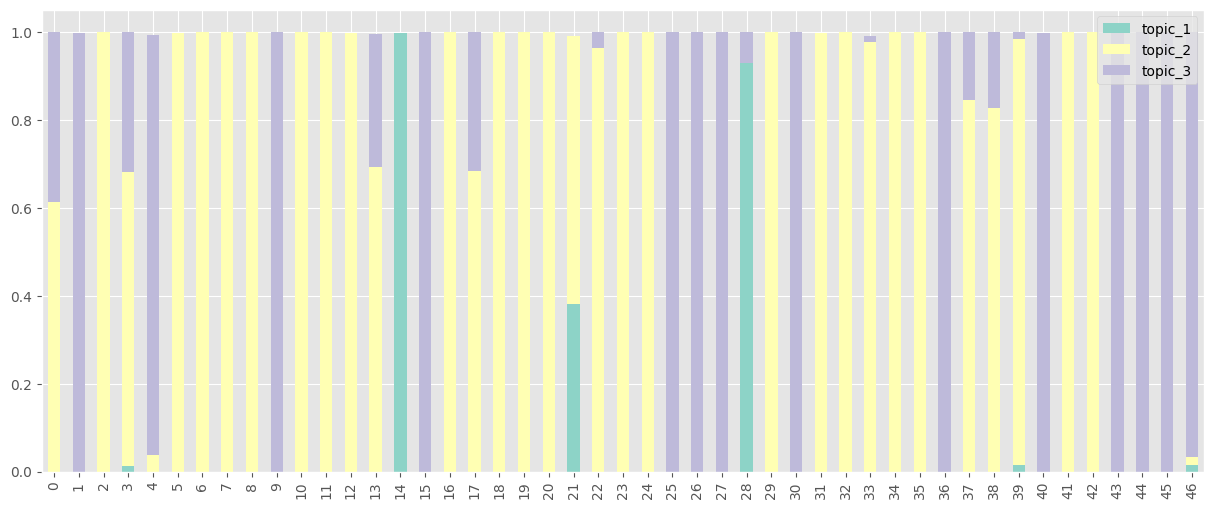

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
theta3.plot.bar(ax=ax, stacked=True, color = plt.cm.Set3.colors)

### 4.2.2 主題機率：四主題

本圖呈現各篇新聞在不同主題下之分布比例。結果顯示，多數文章集中於單一主題，顯示主題模型具有良好的區分能力；然而，部分文章同時包含多個主題，反映新聞內容具備跨議題特性。此外，Topic 2 與 Topic 3 出現頻率較高，顯示其為主要主題，而 Topic 4 則占比相對較低，影響較小。

本研究透過 LDA 主題模型將新聞文本分為四個主要主題。

* Topic 1 以國際政治與軍事衝突為核心。
* Topic 2 聚焦於石油與能源經濟議題。
* Topic 3 描述軍事行動與戰爭細節。
* Topic 4 則反映戰爭對民生與經濟之影響。

<Axes: >

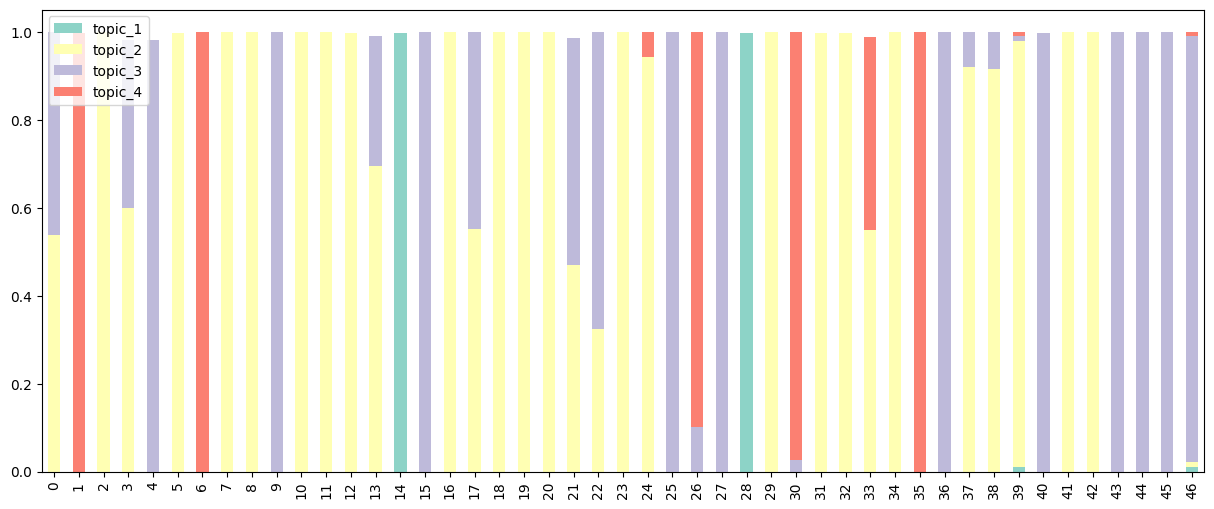

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
theta.plot.bar(ax=ax, stacked=True, color = plt.cm.Set3.colors)

### 4.2.3 主題機率：五主題

<Axes: >

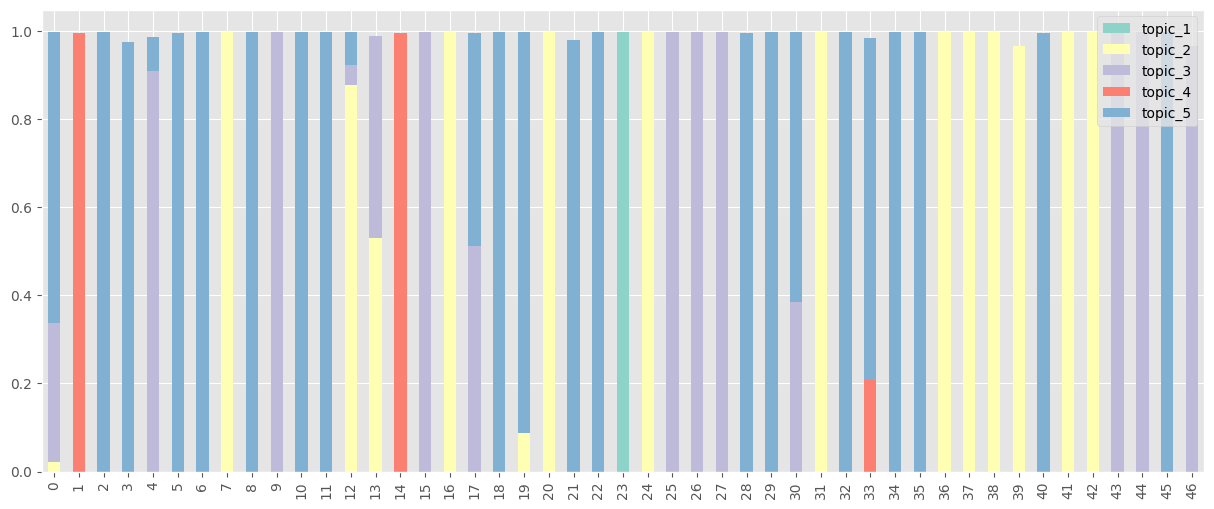

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
theta.plot.bar(ax=ax, stacked=True, color = plt.cm.Set3.colors)